# COGS 108 Final Project - The Recent Tech Landscape 

## Link to video
https://drive.google.com/file/d/1zwJT1MzKJtBk0HuOxsWe4wU94scbi5Cu/view?usp=sharing

## Abstract

We started this project with a question we were all asking ourselves as students getting ready to enter the tech job market: what skills do you actually need, and does it matter what role you're going for? Reports from McKinsey and the World Economic Forum confirmed that technical skill demand is growing fast, but none of that research told us what skills translate to better salaries or higher-level roles at the individual level. We wanted to find that out for ourselves.
    
To investigate this, we analyzed over 25,000 tech-relevant LinkedIn job postings filtered from a dataset of 1.3 million, alongside 93,000 data science salary records from 2024. Our key variables included technical skill frequency, job category, seniority level, salary, and remote work availability. We cleaned and merged these datasets, identified the most demanded skills across five job categories, examined how skill demand shifts between senior and non-senior roles, and trained Random Forest classifiers to test whether skills alone could predict job category and seniority level.

Python and SQL dominated overall demand and confirmed our core hypothesis, but the results got more interesting from there. Our classifier predicted the job category at 82% accuracy but seniority at only 67%, barely better than chance, given our near 50/50 senior to non-senior split, suggesting that seniority reflects experience and judgment that a skills list cannot capture. Salary scaled clearly with experience level rather than specific skills, with distributions heavily right-skewed by high earners. These findings give students and early-career professionals a clearer, more honest picture of a confusing and competitive hiring market.


## Authors

This is a modified [CRediT taxonomy of contributions](https://credit.niso.org). For each group member please list how they contributed to this project using these terms:

Example team list and credits:
- Eric Badilla: Conceptualization, background research, writing (original, review, and editing)
- Nishka Vaghela: Data Science Job data visualization, writing, and video creation
- Niharika Sapre: LinkedIn Dataset EDA & Predictive Modeling, Project Management, and video creation
- Renee Li: Methodology, Writing – original draft, Final Video Slides Design
- Jenny Fu: Project administration, Software, writing, and video creation

## Research Question

What technical skills are demanded in tech and data roles, and how do skill demands, salary, remote work proportions, and seniority vary across the industry? 

## Background and Prior Work

Research has increasingly demonstrated the existence of a persistent gap between the skills learned within academic settings and the skills required within the labor market. According to the report on the Future of Work released by McKinsey (2023)(https://www.mckinsey.com/featured-insights/future-of-work/defining-the-skills-citizens-will-need-in-the-future-world-of-work), more than 40% of the global workforce could potentially require reskilling by the year 2030, with data and technical skills being the areas with the greatest growth rate in terms of demand. Similarly, the Future of Jobs reports released by the World Economic Forum have consistently ranked cloud computing, machine learning, and data analysis as the areas with the greatest growth rate in terms of demand for skills across all industries(https://www.weforum.org/publications/the-future-of-jobs-report-2023/). Although the aforementioned reports have demonstrated the existence of a persistent gap between the skills learned and the skills required within the labor market, they have not specifically examined the relationships between specific labor market outcomes and the skills learned by individuals, which could have a great impact on the decisions of new entrants into the labor market, particularly within the realm of the technical fields.

Some prior studies have already examined the job posting data to understand the skill demand in the tech labor market. To exemplify, the study by Sadafian (2026) examined the data from 1,964 LinkedIn job postings for data-related positions and discovered that the presence of SQL skills appeared in about 55% of the job postings, whereas the presence of Python skills appeared in about 41% of the job postings(https://www.kaggle.com/datasets/arshkon/linkedin-job-postings). Even though this study provides some insights into the labor market, it mainly provides a description of the data and lacks the exploration of the predictive power of the skills on the job posting outcomes. Another study on the LinkedIn Economic Graph(https://economicgraph.linkedin.com/) provides some insights into the labor market trends through the analysis of the LinkedIn data and provides some insights into the labor market trends. However, the study lacks the provision of individual-level job posting data to examine the predictive power of the skills on the job posting outcomes. Therefore, the gap in the literature lies in the exploration of the predictive power of the skills on the job posting outcomes.

The rise of the use of remote work after the year 2020 is an additional factor that can be analyzed. Technical work, such as technology and data work, has maintained the flexibility of working remotely more compared to other industries. This may imply that the nature of technical work is more conducive to flexibility. However, it has been argued that the fact that technology work is done remotely may be attributed to the nature of the work, which is digital-based, or it may be attributed to the fact that companies compete for the best talent. However, the investigation of the nature of the work may provide more clarity regarding the fact that the flexibility of working remotely may be attributed to the nature of the skills, the nature of the organizations, or the nature of the labor market.

Although the data obtained from LinkedIn is useful in understanding hiring trends in the technology industry, it is important to note that it only reflects a fraction of the entire hiring process in the labor market. This is because LinkedIn only accounts for a quarter of the entire online job board market and is biased towards mid-sized and large companies and established technology firms. This means that hiring trends in startup companies are often found on other job search websites like Wellfound, trades and health-related positions are common on websites like Indeed, and some small businesses may not even post their job vacancies online at all. It is thus important to understand that the results obtained from the job postings only reflect hiring trends in corporate technology and data industries.

## Hypothesis


We hypothesize the following:

1. Python, SQL, and cloud platform skills (AWS/GCP/Azure) will be the three most demanded skills across tech and data roles postings.
2. Roles requiring cloud and ML skills will show statistically significantly higher median salaries than roles requiring only general programming skills.
3. Salaries across job modality (remote, hybrid, and in-person) will not differ to a great extent. 
4. We expect that technical jobs that require a more extensive skill set will be higher in seniority, while entry level jobs will have limited required skill sets. 

## Data

### Data overview

This project uses two publicly available datasets to investigate technical skill demand, compensation, and remote work patterns in tech and data roles.

**Dataset #1: Latest Data Science Job Salaries 2024** 

Dataset Name: Latest Data Science Job Salaries 2024
Link: https://www.kaggle.com/datasets/saurabhbadole/latest-data-science-job-salaries-2024?resource=download
Key variables: salary_in_usd, experience_level (EN/MI/SE/EX), employment_type, job_title, remote_ratio (0/50/100), company_location, company_size
Shortcomings: Compiled from publicly available salary records; likely overrepresents companies with salary transparency policies. Job titles vary widely across the industry, requiring normalization before analysis.

**Dataset #2: LinkedIn Jobs and Skills 2024**

Dataset Name: LinkedIn Jobs and Skills 2024
Link: https://www.kaggle.com/datasets/asaniczka/1-3m-linkedin-jobs-and-skills-2024/code
Number of observations: Over 1.3 million job postings
Key variables: job title, required skills, seniority level, salary range, work type (remote/hybrid/on-site), company name, location
Shortcomings: LinkedIn represents only a fraction of the total job market and is skewed toward mid-sized and large companies. Roles filled through referrals, internal hiring, or campus recruiting are not captured.

The two datasets will be combined by aligning seniority level and job title fields. Dataset 1 provides skill demand across job type, company location, and seniority. Dataset 2 provides insights on salaries and work modality. Together they enable cross-referencing of skills, seniority, compensation, and work flexibility.



### Imports 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print('Libraries loaded.')

Libraries loaded.


**NOTE** The final report should not be overly long.  If this wrangling step is huge and complicated you should remove these sections from the final report and replace them with a statement like "To see the code responsible for wrangling the data see `01-DataCheckpoint.ipynb`. From here on we will simply load the processed data for further analysis"

#### DATASET 1: Latest Data Science Job Salaries 2024

 https://www.kaggle.com/datasets/saurabhbadole/latest-data-science-job-salaries-2024?resource=download

The Latest Data Science Job Salaries 2024 dataset contains salary and job information for data-related roles across multiple companies, countries, and experience levels. Each row represents one job record and includes variables such as salary, job title, experience level, company location, remote work ratio, and company size. This dataset is useful for analyzing compensation trends and employment patterns in the data science industry.

One of the most important variables is salary_in_usd, which records yearly salary in U.S. dollars. This variable is numerical and represents annual compensation for a given role. In general, lower values tend to reflect entry-level jobs, while higher values are more common in senior or specialized roles. Because salaries are already converted into U.S. dollars, this variable makes comparisons across countries more meaningful.

Another key variable is experience_level, which groups employees into four categories: Entry-level (EN), Mid-level (MI), Senior-level (SE), and Executive-level (EX). These categories represent different career stages and help show how salary and job characteristics vary by experience. The dataset also includes employment_type (such as full-time, part-time, contract, or freelance), job_title, and company_size (small, medium, or large).

The dataset also includes remote_ratio, which describes how much of the work is done remotely. This variable is measured as 0, 50, or 100, where 0 means fully in-person, 50 means hybrid, and 100 means fully remote. This is important for understanding differences in workplace flexibility across data-related jobs. Other useful variables include company_location and employee_residence, which describe geographic location.

There are several concerns with this dataset. First, it may not represent the entire job market because it is based on publicly available salary information rather than a random sample of all workers. This may over-represent companies or countries where salary data is more available. Second, salary values can vary widely by company, location, and role, so some entries may appear unusually high or low. Third, job titles in data science are often inconsistent, so similar roles may appear under different names and may need additional cleaning or grouping. Despite these limitations, the dataset provides a useful overview of salary trends and employment characteristics in the data science field.


#### Load the dataset

In [2]:
df = pd.read_csv("DS_dataset/DataScience_salaries_2025.csv")

#### Initial dataset examination 

In [3]:
print("Dataset shape (rows, columns):", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn names:")
print(df.columns)
print("\nData types:")
print(df.dtypes)
print("\nPreview of dataset:")
print(df.head())

Dataset shape (rows, columns): (93597, 11)
Number of rows: 93597
Number of columns: 11

Column names:
Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

Data types:
work_year              int64
experience_level      object
employment_type       object
job_title             object
salary                 int64
salary_currency       object
salary_in_usd          int64
employee_residence    object
remote_ratio           int64
company_location      object
company_size          object
dtype: object

Preview of dataset:
   work_year experience_level employment_type           job_title  salary  \
0       2025               MI              FT  Research Scientist  208000   
1       2025               MI              FT  Research Scientist  147000   
2       2025               SE              FT  Research Scientist  1730

#### Null columns

In [4]:
#Check to find null columns
null_counts = df.isnull().sum()
null_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": null_counts,
    "Percent Missing": null_percent
    })

print("\nMissing data summary:")
print(missing_summary.sort_values(by="Percent Missing", ascending=False))

#Identify columns that are entirely null
null_columns = df.columns[df.isnull().all()]
print("\nColumns with all null values:")
print(null_columns)

# 6. Inspect patterns of missingness
# Checking whether missingness correlates with other columns
print("\nMissing values by column:")
print(df.isnull().sum())


Missing data summary:
                    Missing Values  Percent Missing
work_year                        0              0.0
experience_level                 0              0.0
employment_type                  0              0.0
job_title                        0              0.0
salary                           0              0.0
salary_currency                  0              0.0
salary_in_usd                    0              0.0
employee_residence               0              0.0
remote_ratio                     0              0.0
company_location                 0              0.0
company_size                     0              0.0

Columns with all null values:
Index([], dtype='object')

Missing values by column:
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype

#### Data Cleaning 

In [5]:
# Convert salary columns to numeric 
salary_cols = [col for col in df.columns if "salary" in col.lower()]

for col in salary_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Detect outliers
for col in salary_cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        print(f"\nOutliers detected in {col}: {len(outliers)}")

# Remove rows that are missing important information
# For this project we'll use job title, skills, and seniority
critical_cols = [col for col in df.columns if any(x in col.lower() for x in ["title","skill","senior"])]
df_clean = df.dropna(subset=critical_cols)

# Remove duplicate job postings
df_clean = df_clean.drop_duplicates()

# Basic cleaning of skills column
skills_cols = [col for col in df_clean.columns if "skill" in col.lower()]

for col in skills_cols:
    df_clean[col] = df_clean[col].astype(str).str.lower().str.strip()


Outliers detected in salary: 2006

Outliers detected in salary_currency: 0

Outliers detected in salary_in_usd: 2024


#### New Size & Summary Stats 

In [6]:
print("\nFinal cleaned dataset shape:", df_clean.shape)
print("\nSummary statistics:")
print(df_clean["salary_in_usd"].describe())

print("\nExperience level counts:")
print(df_clean["experience_level"].value_counts())


Final cleaned dataset shape: (46637, 11)

Summary statistics:
count     46637.000000
mean     151411.819993
std       77492.347696
min       15000.000000
25%       96400.000000
50%      139100.000000
75%      190500.000000
max      800000.000000
Name: salary_in_usd, dtype: float64

Experience level counts:
experience_level
SE    24749
MI    15049
EN     5391
EX     1448
Name: count, dtype: int64


#### Save cleaned dataset

In [7]:
os.makedirs("data/02-processed", exist_ok=True)
df_clean.to_csv("data/02-processed/linkedin_jobs_clean.csv", index=False)

print("\nClean dataset saved to data/02-processed/")


Clean dataset saved to data/02-processed/


### DATASET 2 & 3: LinkedIn Jobs and Skills Postings (which will get merged)
https://www.kaggle.com/datasets/asaniczka/1-3m-linkedin-jobs-and-skills-2024/code

The LinkedIn Jobs and Skills 2024 dataset contains over 1.3 million job postings collected from LinkedIn. Each row represents a single job posting and includes information such as job title, skills, seniority level, salary estimates, remote or work type, company name, and location. This makes the dataset useful for studying hiring patterns across many roles, industries, and locations.

The most important variables for this project are job title, skills, seniority level, salary information, and work type / remote status. The job title identifies the position being advertised, such as Data Scientist or Software Engineer. The skills field lists the technical and professional skills requested by employers, which helps show which tools and technologies are most in demand. The seniority level variable indicates the experience level required for the role, such as Entry-level, Associate, Mid-Senior, Director, or Executive. Salary information, when available, provides estimated pay ranges, and work type / remote status shows whether the job is on-site, hybrid, or fully remote.

These variables are important because they allow the dataset to capture both skill demand and job characteristics in the same posting. For example, the dataset can be used to compare which skills appear most often in tech and data roles, how those skills change across career stages, and whether salary and remote-work opportunities differ by seniority level.

There are also some concerns with this dataset. First, it only includes jobs posted on LinkedIn, so it may not represent the entire job market. Second, some fields, especially salary information, may be missing or inconsistent across postings. Third, skills may be listed in different formats or spellings, which means they may need additional cleaning before analysis. Despite these limitations, the dataset is well suited for this project because it provides detailed posting-level information on skills, seniority, salary, and remote work.

In [8]:
df_postings = pd.read_csv("LinkedIn_dataset/linkedin_job_postings.csv")
df_skills = pd.read_csv("LinkedIn_dataset/job_skills.csv")

### Job Postings CSV

#### Initial Postings

In [9]:
print('Linkedin Job Postings CSV')
print(f'Shape: {df_postings.shape}')
print(f'Columns: {list(df_postings.columns)}')
df_postings.head(10)

Linkedin Job Postings CSV
Shape: (1348454, 14)
Columns: ['job_link', 'last_processed_time', 'got_summary', 'got_ner', 'is_being_worked', 'job_title', 'company', 'job_location', 'first_seen', 'search_city', 'search_country', 'search_position', 'job_level', 'job_type']


,job_link,last_processed_time,got_summary,got_ner,is_being_worked,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type
0,https://www.linkedin.com/jobs/view/account-exe...,2024-01-21 07:12:29.00256+00,t,t,f,Account Executive - Dispensing (NorCal/Norther...,BD,"San Diego, CA",2024-01-15,Coronado,United States,Color Maker,Mid senior,Onsite
1,https://www.linkedin.com/jobs/view/registered-...,2024-01-21 07:39:58.88137+00,t,t,f,Registered Nurse - RN Care Manager,Trinity Health MI,"Norton Shores, MI",2024-01-14,Grand Haven,United States,Director Nursing Service,Mid senior,Onsite
2,https://www.linkedin.com/jobs/view/restaurant-...,2024-01-21 07:40:00.251126+00,t,t,f,RESTAURANT SUPERVISOR - THE FORKLIFT,Wasatch Adaptive Sports,"Sandy, UT",2024-01-14,Tooele,United States,Stand-In,Mid senior,Onsite
3,https://www.linkedin.com/jobs/view/independent...,2024-01-21 07:40:00.308133+00,t,t,f,Independent Real Estate Agent,Howard Hanna | Rand Realty,"Englewood Cliffs, NJ",2024-01-16,Pinehurst,United States,Real-Estate Clerk,Mid senior,Onsite
4,https://www.linkedin.com/jobs/view/group-unit-...,2024-01-19 09:45:09.215838+00,f,f,f,Group/Unit Supervisor (Systems Support Manager...,"IRS, Office of Chief Counsel","Chamblee, GA",2024-01-17,Gadsden,United States,Supervisor Travel-Information Center,Mid senior,Onsite
5,https://www.linkedin.com/jobs/view/counselor-0...,2024-01-19 09:45:09.215838+00,f,f,f,Counselor-07532802,ICL,"Brooklyn, NY",2024-01-16,Oyster Bay,United States,Residence Counselor,Mid senior,Onsite
6,https://www.linkedin.com/jobs/view/registered-...,2024-01-21 08:08:19.663033+00,t,t,f,Registered Nurse (RN),Trinity Health MI,"Muskegon, MI",2024-01-14,Muskegon,United States,Nurse Practitioner,Mid senior,Onsite
7,https://www.linkedin.com/jobs/view/part-time-h...,2024-01-21 08:08:19.912883+00,t,t,f,Part Time- HR Generalist,Creative Financial Staffing (CFS),"New York, NY",2024-01-16,White Plains,United States,Human Resource Advisor,Mid senior,Onsite
8,https://uk.linkedin.com/jobs/view/store-manage...,2024-01-21 08:08:20.658147+00,t,t,f,Store Manager,B&M Retail,"London, England, United Kingdom",2024-01-15,Slough,United Kingdom,Double,Mid senior,Onsite
9,https://ca.linkedin.com/jobs/view/engineering-...,2024-01-21 08:08:20.998834+00,t,t,f,Engineering Project Coordinator,Shared Health-Soins Communs,"Winnipeg, Manitoba, Canada",2024-01-14,Manitoba,Canada,Program Coordinator,Mid senior,Onsite


In [10]:
print(f'\nNull counts:\n{df_postings.isnull().sum()}')


Null counts:
job_link                0
last_processed_time     0
got_summary             0
got_ner                 0
is_being_worked         0
job_title               0
company                11
job_location           19
first_seen              0
search_city             0
search_country          0
search_position         0
job_level               0
job_type                0
dtype: int64


Null values: Only 11 null companies and 19 null locations out of 1.3M rows - this dataset is very clean!

#### Looking into Postings Dataset Further 
Jobs are either Mid Senior or Associate level. Look at how many of each type there are! 

In [11]:
print('job_level values:')
print(df_postings['job_level'].value_counts(dropna=False))

job_level values:
job_level
Mid senior    1204445
Associate      144009
Name: count, dtype: int64


Jobs are either Onsite, Hybrid, or remote. Find out value counts! 

In [12]:
print('job_type values:')
print(df_postings['job_type'].value_counts(dropna=False))

job_type values:
job_type
Onsite    1337633
Hybrid       6562
Remote       4259
Name: count, dtype: int64


### Skills CSV

#### Initial Looks

In [13]:
print('Job Skills CSV')
print(f'Shape: {df_skills.shape}')
print(f'Columns: {list(df_skills.columns)}')
print(f'\nFirst 10 rows:')
print(f'\nNull counts:\n{df_skills.isnull().sum()}')
df_skills.head(10)

Job Skills CSV
Shape: (1296381, 2)
Columns: ['job_link', 'job_skills']

First 10 rows:

Null counts:
job_link         0
job_skills    2085
dtype: int64


,job_link,job_skills
0,https://www.linkedin.com/jobs/view/housekeeper...,"Building Custodial Services, Cleaning, Janitor..."
1,https://www.linkedin.com/jobs/view/assistant-g...,"Customer service, Restaurant management, Food ..."
2,https://www.linkedin.com/jobs/view/school-base...,"Applied Behavior Analysis (ABA), Data analysis..."
3,https://www.linkedin.com/jobs/view/electrical-...,"Electrical Engineering, Project Controls, Sche..."
4,https://www.linkedin.com/jobs/view/electrical-...,"Electrical Assembly, Point to point wiring, St..."
5,https://www.linkedin.com/jobs/view/senior-lead...,"Access Control, Video Management Systems, IPba..."
6,https://www.linkedin.com/jobs/view/program-con...,"Consultation, Supervision, InService Training,..."
7,https://www.linkedin.com/jobs/view/veterinary-...,"Veterinary Receptionist, AAHAaccredited, Custo..."
8,https://www.linkedin.com/jobs/view/sr-technici...,"Optical Inspection Equipment Programming, MS E..."
9,https://www.linkedin.com/jobs/view/experienced...,"HVAC, troubleshooting, Preventative maintenanc..."


The dataset only has the job link and skills associated with each job. 

#### Before Merging datasets...
Looking into how many job posting have skill descriptions. 

In [14]:
print(f'\nUnique job_links in postings: {df_postings["job_link"].nunique():,}')
print(f'Unique job_links in skills:   {df_skills["job_link"].nunique():,}')
print(f'Overlap: {len(set(df_postings["job_link"]) & set(df_skills["job_link"])):,}')


Unique job_links in postings: 1,348,454
Unique job_links in skills:   1,296,381
Overlap: 1,296,381


The overlap is 1,296,381 meaning every skills link has a corresponding posting from the postings dataset. There are 52,073 extra postings with no skills description from the skills CSV. 

##### Cleaning the Postings CSV to be Tech Focused

Drop junk columns

In [15]:
df_postings.drop(columns=['got_summary', 'got_ner', 'is_being_worked'], inplace=True)

print(f'Remaining columns: {list(df_postings.columns)}')
print(f'Shape: {df_postings.shape}')

Remaining columns: ['job_link', 'last_processed_time', 'job_title', 'company', 'job_location', 'first_seen', 'search_city', 'search_country', 'search_position', 'job_level', 'job_type']
Shape: (1348454, 11)


Now, we only want to keep tech jobs in our postings CSV. So, we have created a filter wih keywords based on looking at some sample job titles manually. 

In [16]:
TECH_KEYWORDS = [
    'data analyst', 'data scientist', 'data engineer',
    'machine learning', 'ml engineer', 'ai engineer',
    'software engineer', 'software developer',
    'business analyst', 'business intelligence',
    'analytics engineer', 'quantitative analyst',
    'data specialist', 'python developer',
    'backend engineer', 'frontend engineer',
    'full stack', 'cloud engineer', 'devops',
    'bi analyst', 'reporting analyst', 'database engineer',
    'etl developer', 'data architect'
]

#turns the list into a single regex pattern:
pattern = '|'.join(TECH_KEYWORDS)

#record length of df_postings with all job types in n_before
n_before = len(df_postings)

#now check if the job title contains any of those strings in pattern
#shorten df_postings dataset to only include jobs containing these strings
df_postings = df_postings[
    df_postings['job_title'].str.lower().str.contains(pattern, na=False)
].copy().reset_index(drop=True)

#count how many tech jobs now (aka total postings in filtered dataset)
n_after = len(df_postings)

print(f'Before: {n_before:,}')
print(f'After:  {n_after:,}')
print(f'Dropped: {n_before - n_after:,}')
print(f'\nTop 20 job titles after filter:')
print(df_postings['job_title'].str.lower().str.strip().value_counts().head(20).to_string())

Before: 1,348,454
After:  25,676
Dropped: 1,322,778

Top 20 job titles after filter:
job_title
business analyst                                 1024
senior software engineer                          974
senior embedded software engineer                 324
software engineer                                 321
senior data engineer                              292
senior business analyst                           214
senior backend engineer                           204
lead software engineer                            194
senior software developer                         191
senior data analyst                               167
jde business analyst (supply chain)               163
data engineer                                     154
jd edwards business analyst                       150
sr. software engineer                             147
senior software engineer, distributed systems     146
data analyst                                      144
data scientist                           

Updated df_postings has 25,676 tech roles

Visualize this! And save in plots folder

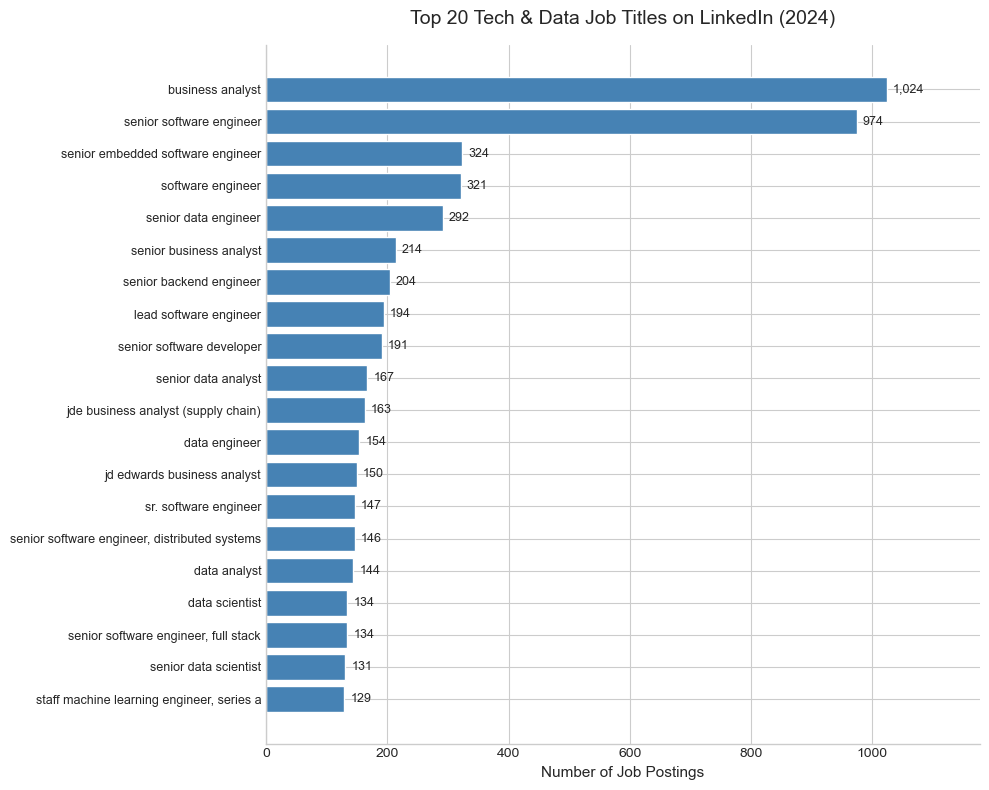

Saved to plots/top20_job_titles.png


In [17]:
import os
os.makedirs('plots', exist_ok=True)

title_counts = df_postings['job_title'].str.lower().str.strip().value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(
    title_counts.index[::-1],
    title_counts.values[::-1],
    color='steelblue',
    edgecolor='white'
)

# Add count labels on each bar
for bar, count in zip(bars, title_counts.values[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=9)

ax.set_title('Top 20 Tech & Data Job Titles on LinkedIn (2024)', fontsize=14, pad=15)
ax.set_xlabel('Number of Job Postings', fontsize=11)
ax.set_xlim(0, title_counts.max() * 1.15)
ax.tick_params(axis='y', labelsize=9)
sns.despine()

plt.tight_layout()
plt.savefig('plots/top20_job_titles.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved to plots/top20_job_titles.png')

In [18]:
# Check job_level distribution after title filter
print('job_level after title filter:')
print(df_postings['job_level'].value_counts())

job_level after title filter:
job_level
Mid senior    23474
Associate      2202
Name: count, dtype: int64


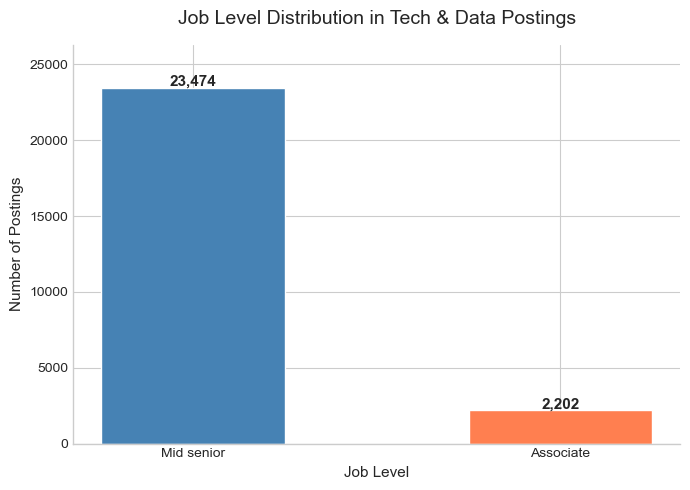

In [19]:
level_counts = df_postings['job_level'].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    level_counts.index,
    level_counts.values,
    color=['steelblue', 'coral'],
    edgecolor='white',
    width=0.5
)

for bar, count in zip(bars, level_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{count:,}', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Job Level Distribution in Tech & Data Postings', fontsize=14, pad=15)
ax.set_xlabel('Job Level', fontsize=11)
ax.set_ylabel('Number of Postings', fontsize=11)
ax.set_ylim(0, level_counts.max() * 1.12)
sns.despine()

plt.tight_layout()
plt.savefig('plots/job_level_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

It may be more informative to see if roles are senior vs not senior. 

In [20]:
# Check how many senior vs non-senior titles we have
df_postings['is_senior'] = df_postings['job_title'].str.lower().str.contains(
    'senior|sr\.|lead|staff|principal|head of', na=False
)
print('Senior vs non-senior titles:')
print(df_postings['is_senior'].value_counts())
print(f'\nPct senior: {df_postings["is_senior"].mean():.1%}')

Senior vs non-senior titles:
is_senior
True     13450
False    12226
Name: count, dtype: int64

Pct senior: 52.4%


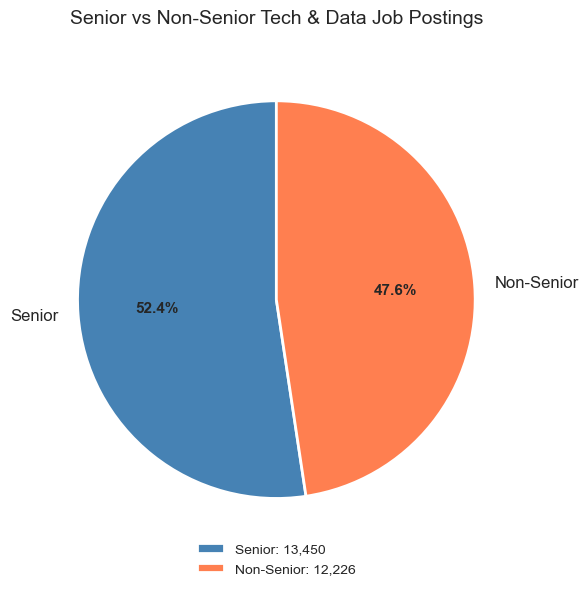

In [21]:
senior_counts = df_postings['is_senior'].value_counts()
labels = ['Senior', 'Non-Senior']
values = [senior_counts[True], senior_counts[False]]
colors = ['steelblue', 'coral']

fig, ax = plt.subplots(figsize=(6, 6))

wedges, texts, autotexts = ax.pie(
    values,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)

for text in texts:
    text.set_fontsize(12)
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

ax.set_title('Senior vs Non-Senior Tech & Data Job Postings', fontsize=14, pad=20)

# Add raw counts as a legend
legend_labels = [f'{label}: {count:,}' for label, count in zip(labels, values)]
ax.legend(legend_labels, loc='lower center', bbox_to_anchor=(0.5, -0.08), fontsize=10)

plt.tight_layout()
plt.savefig('plots/senior_vs_nonsenior.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
print('Non-senior job titles (top 20):')
print(
    df_postings[df_postings['is_senior'] == False]['job_title']
    .str.lower().str.strip()
    .value_counts()
    .head(20)
    .to_string()
)

Non-senior job titles (top 20):
job_title
business analyst                                         1024
software engineer                                         321
jde business analyst (supply chain)                       163
data engineer                                             154
jd edwards business analyst                               150
data analyst                                              144
data scientist                                            134
data architect                                            117
software engineer iii                                     109
business intelligence analyst                             101
founding software engineer, seed stage                     95
embedded software engineer                                 86
manager, devops - remote                                   79
software developer                                         78
devops engineer                                            68
it business analyst         

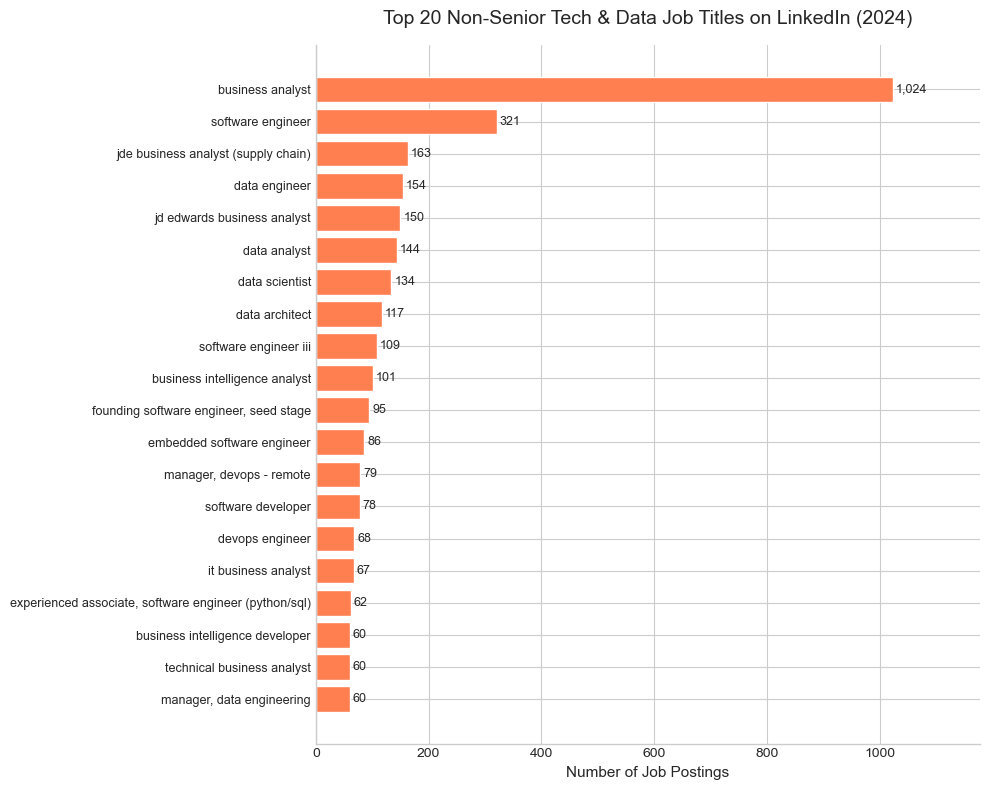

In [23]:
nonsenior_counts = (
    df_postings[df_postings['is_senior'] == False]['job_title']
    .str.lower().str.strip()
    .value_counts()
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(
    nonsenior_counts.index[::-1],
    nonsenior_counts.values[::-1],
    color='coral',
    edgecolor='white'
)

for bar, count in zip(bars, nonsenior_counts.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=9)

ax.set_title('Top 20 Non-Senior Tech & Data Job Titles on LinkedIn (2024)', fontsize=14, pad=15)
ax.set_xlabel('Number of Job Postings', fontsize=11)
ax.set_xlim(0, nonsenior_counts.max() * 1.15)
ax.tick_params(axis='y', labelsize=9)
sns.despine()

plt.tight_layout()
plt.savefig('plots/top20_nonsenior_titles.png', dpi=150, bbox_inches='tight')
plt.show()

### Merge Cleaned Postings Dataset w/ Skills Dataset

In [24]:
df = df_postings.merge(df_skills, on='job_link', how='left')

In [25]:
# Fill nulls with empty string before splitting
df['job_skills'] = df['job_skills'].fillna('')

# Parse comma-separated skills into a list
df['skills_list'] = df['job_skills'].apply(
    lambda x: [s.strip() for s in x.split(',') if s.strip()]
)

print(f'Shape after join: {df.shape}')
#count empty string lists 
print(f'Rows with no skills: {df["skills_list"].apply(len).eq(0).sum():,}')
print(f'\nSample parsed skills:')
for row in df[df['skills_list'].apply(len) > 0]['skills_list'].head(5):
    print(row)

Shape after join: (25676, 14)
Rows with no skills: 1,001

Sample parsed skills:
['Distributed Microservices', 'Machine Learning Operations (MLOps)', 'Kubernetes', 'Golang', 'Python', 'AWS', 'Microsoft Azure', 'Google Cloud', 'Kubernetes Operator Development', 'Devops', 'Machine Learning']
['DevOps', 'Cloud Native technologies', 'Amazon Web Services', 'Microsoft Azure', 'Google Cloud Platform', 'Windows', 'Unix', 'Linux system administration', 'Microsoft Endpoint Configuration Manager (MECM)', 'Powershell', 'SQL', 'Python', 'Java', 'JavaScript', 'Golang', 'Bash', 'Perl', 'Ruby', 'Microsoft PowerBI', 'Terraform', 'Ansible', 'Agile Development Practices']
['Machine Learning', 'Programming', 'Python', 'Scala', 'Java', 'Data Engineering', 'Distributed Computing', 'Statistical Modeling', 'Optimization', 'Data Pipelines', 'Cloud Computing', 'DevOps', 'Software Development', 'Data Gathering', 'Data Preparation', 'Data Visualization', 'Machine Learning Frameworks', 'scikitlearn', 'PyTorch', 'Da

In [26]:
os.makedirs("data/02-processed", exist_ok=True)

df_clean.to_csv("data/02-processed/merged_jobs_skills.csv", index=False)

print("\nCleaned dataset saved to data/02-processed/")


Cleaned dataset saved to data/02-processed/


In [27]:
df

,job_link,last_processed_time,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type,is_senior,job_skills,skills_list
0,https://www.linkedin.com/jobs/view/senior-soft...,2024-01-19 09:45:09.215838+00,Senior Software Engineer - Backend,Walmart,"Reston, VA",2024-01-15,Bethesda-Chevy Chase,United States,Chief Computer Programmer,Mid senior,Onsite,True,,[]
1,https://www.linkedin.com/jobs/view/lead-softwa...,2024-01-21 07:43:52.624477+00,"Lead Software Engineer, Back End",ClickJobs.io,"Poughkeepsie, NY",2024-01-14,New Windsor,United States,Job Development Specialist,Mid senior,Onsite,True,"Distributed Microservices, Machine Learning Op...","[Distributed Microservices, Machine Learning O..."
2,https://www.linkedin.com/jobs/view/asset-wealt...,2024-01-19 09:45:09.215838+00,Asset & Wealth Management- Senior Software Eng...,Goldman Sachs,"New York, NY",2024-01-15,New York,United States,Chief Computer Programmer,Mid senior,Onsite,True,,[]
3,https://www.linkedin.com/jobs/view/senior-soft...,2024-01-21 08:08:44.927905+00,"Senior Software Engineer, DevOps",Jobs for Humanity,"Atlantic City, NJ",2024-01-14,Ocean City,United States,Manager Employment,Mid senior,Onsite,True,"DevOps, Cloud Native technologies, Amazon Web ...","[DevOps, Cloud Native technologies, Amazon Web..."
4,https://www.linkedin.com/jobs/view/senior-mach...,2024-01-21 08:08:48.031964+00,Senior Machine Learning Engineer,Jobs for Humanity,"New Haven, CT",2024-01-14,East Haven,United States,Agricultural-Research Engineer,Mid senior,Onsite,True,"Machine Learning, Programming, Python, Scala, ...","[Machine Learning, Programming, Python, Scala,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25671,https://www.linkedin.com/jobs/view/senior-data...,2024-01-19 23:25:28.107523+00,Senior Data Engineer,CompSource Mutual Insurance Company,"Oklahoma City, OK",2024-01-16,Arcadia,United States,Protection Engineer,Mid senior,Onsite,True,"Data Engineering, Data Quality, SQL, Python, T...","[Data Engineering, Data Quality, SQL, Python, ..."
25672,https://www.linkedin.com/jobs/view/lead-softwa...,2024-01-19 23:26:09.60373+00,"Lead Software Engineer, Back End",Jobs for Humanity,"Hartford, CT",2024-01-14,Springfield,United States,Developer,Mid senior,Onsite,True,"Back End Software Engineering, Distributed Mic...","[Back End Software Engineering, Distributed Mi..."
25673,https://www.linkedin.com/jobs/view/looking-for...,2024-01-19 09:45:09.215838+00,Looking for Sr. Build and Release DevOps Engin...,MillenniumSoft Inc,"San Jose, CA",2024-01-16,Santa Clara,United States,Packer,Mid senior,Onsite,True,,[]
25674,https://www.linkedin.com/jobs/view/software-en...,2024-01-21 07:12:28.929471+00,Software Engineer 3 w/ 20 years experience,"Onyx Point, LLC.","Annapolis Junction, MD",2024-01-14,Laurel,United States,Job Development Specialist,Mid senior,Onsite,False,"Agile software development, Software design, S...","[Agile software development, Software design, ..."


Count frequency of skills, find out which ones are most common in tech postings

In [28]:
# Lowercase all skills
df['skills_list'] = df['skills_list'].apply(
    lambda skills: [s.lower().strip() for s in skills]
)

# Get flat frequency count of all skills
from collections import Counter

all_skills = Counter(
    skill for skills in df['skills_list'] for skill in skills
)

print(f'Total skill mentions: {sum(all_skills.values()):,}')
print(f'Unique skills: {len(all_skills):,}')
print(f'\nTop 50 most common skills:')
for skill, count in all_skills.most_common(50):
    print(f'  {count:>6,}  {skill}')

Total skill mentions: 632,347
Unique skills: 95,980

Top 50 most common skills:
   9,653  python
   8,222  sql
   6,310  java
   5,694  aws
   4,869  communication
   4,674  data analysis
   4,363  software engineering
   3,881  agile
   3,861  kubernetes
   3,585  docker
   3,573  javascript
   3,398  software development
   3,333  machine learning
   3,094  project management
   3,046  problem solving
   2,806  communication skills
   2,730  data visualization
   2,637  cloud computing
   2,539  teamwork
   2,485  computer science
   2,417  devops
   2,398  collaboration
   2,386  c++
   2,340  analytical skills
   2,261  git
   2,254  business analysis
   2,251  linux
   2,221  bachelor's degree
   2,219  azure
   2,173  problemsolving
   2,136  go
   2,077  typescript
   2,018  tableau
   1,906  react
   1,877  nosql
   1,787  scala
   1,740  jira
   1,703  leadership
   1,695  unit testing
   1,658  c#
   1,636  data science
   1,596  data engineering
   1,558  agile development
 

In [29]:
SKILL_NORMALIZATION = {
    # Communication variants
    'communication skills': 'communication',
    'verbal communication': 'communication',
    'written communication': 'communication',
    # Problem solving variants
    'problemsolving': 'problem solving',
    'problem-solving': 'problem solving',
    # Agile variants
    'agile development': 'agile',
    'agile development practices': 'agile',
    'agile methodology': 'agile',
    'agile methodologies': 'agile',
    # Cloud variants
    'amazon web services': 'aws',
    'amazon web services (aws)': 'aws',
    'microsoft azure': 'azure',
    'google cloud platform': 'gcp',
    'google cloud platform (gcp)': 'gcp',
    'google cloud': 'gcp',
    # Data variants
    'data analytics': 'data analysis',
    'data analysis skills': 'data analysis',
    # ML variants
    'machine learning (ml)': 'machine learning',
    'ml': 'machine learning',
    # SQL variants
    'mysql': 'sql',
    'postgresql': 'sql',
    'microsoft sql server': 'sql',
    't-sql': 'sql',
    'pl/sql': 'sql',
    # Spark variants
    'apache spark': 'spark',
    'pyspark': 'spark',
    # Scikit-learn variants
    'scikit-learn': 'scikit-learn',
    'scikitlearn': 'scikit-learn',
    'sklearn': 'scikit-learn',
    # Power BI variants
    'microsoft power bi': 'power bi',
    'microsoft powerbi': 'power bi',
    'powerbi': 'power bi',
    # Other
    'node.js': 'node.js',
    'nodejs': 'node.js',
    'react.js': 'react',
    'reactjs': 'react',
    'tensorflow 2': 'tensorflow',
    'docker container': 'docker',
    'containerization': 'docker',
    'git/github': 'git',
    'github': 'git',
    'gitlab': 'git',
}

# Skills to exclude entirely from feature matrix
# includes soft skills, credentials, generic requirements
EXCLUDE_SKILLS = {
    'communication', 'teamwork', 'collaboration', 'leadership',
    'problem solving', 'analytical skills', 'attention to detail',
    'project management', 'time management', 'critical thinking',
    'interpersonal skills', 'organizational skills', 'multitasking',
    'bachelor\'s degree', 'master\'s degree', 'computer science',
    'software engineering', 'software development', 'data science',
    'data engineering', 'data analytics', 'programming',
}

#normalize_skills is function which cleans the list into only tech skills
def normalize_skills(skills):
    normalized = []
    for s in skills:
        s = SKILL_NORMALIZATION.get(s, s)
        if s not in EXCLUDE_SKILLS:
            normalized.append(s)
    return list(dict.fromkeys(normalized))  # deduplicate

df['skills_normalized'] = df['skills_list'].apply(normalize_skills)

# Recheck top 50 after normalization
#all_skills_norm is the counter which knows how often each skill appears 
all_skills_norm = Counter(
    skill for skills in df['skills_normalized'] for skill in skills
)

print(f'Unique skills after normalization: {len(all_skills_norm):,}')
print(f'\nTop 50 after normalization:')
for skill, count in all_skills_norm.most_common(50):
    print(f'  {count:>6,}  {skill}')

Unique skills after normalization: 95,923

Top 50 after normalization:
   9,554  python
   9,185  sql
   6,714  agile
   6,244  java
   5,868  data analysis
   5,773  aws
   3,828  kubernetes
   3,709  docker
   3,547  javascript
   3,377  machine learning
   3,049  azure
   2,969  git
   2,661  data visualization
   2,619  cloud computing
   2,401  devops
   2,380  c++
   2,326  react
   2,305  gcp
   2,236  business analysis
   2,231  linux
   2,121  go
   2,052  typescript
   1,977  tableau
   1,937  spark
   1,893  power bi
   1,862  nosql
   1,776  scala
   1,709  jira
   1,670  unit testing
   1,651  c#
   1,587  node.js
   1,533  microservices
   1,522  data modeling
   1,462  r
   1,416  business intelligence
   1,412  scrum
   1,404  data warehousing
   1,399  jenkins
   1,396  kafka
   1,347  testing
   1,343  documentation
   1,317  troubleshooting
   1,312  angular
   1,267  ci/cd
   1,246  html
   1,215  css
   1,202  hadoop
   1,164  data management
   1,163  terraform
  

## Results

### Dataset 1 Visualizations

##### Salary Distribution

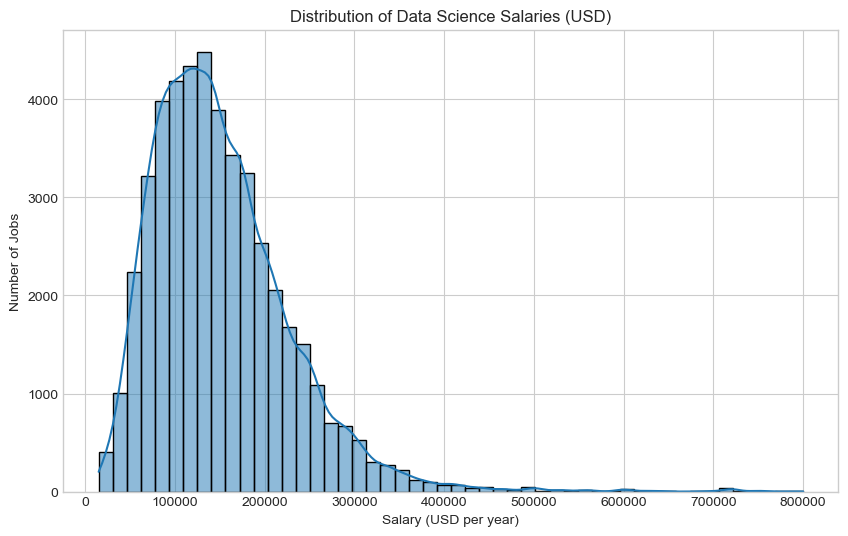

In [30]:
plt.figure(figsize=(10,6))
sns.histplot(df_clean["salary_in_usd"], bins=50, kde=True)
plt.title("Distribution of Data Science Salaries (USD)")
plt.xlabel("Salary (USD per year)")
plt.ylabel("Number of Jobs")
plt.show()

##### Salary by Experience Level

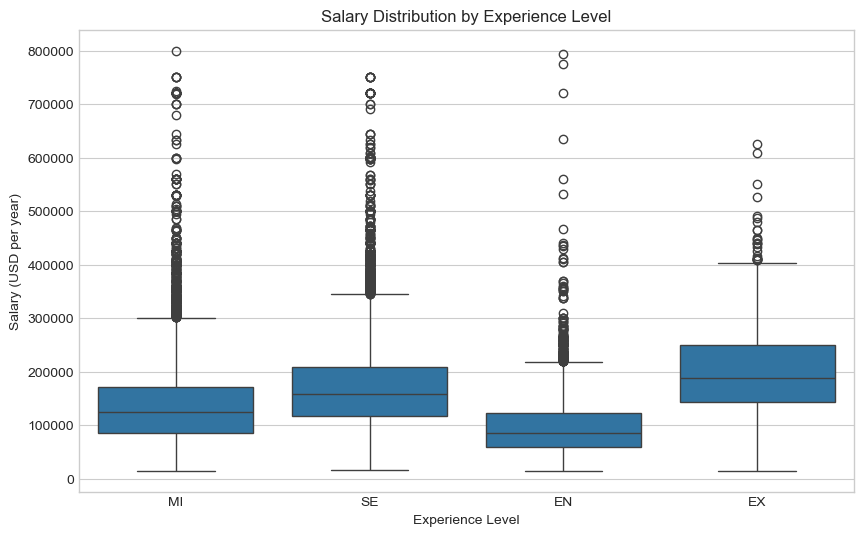

In [31]:
plt.figure(figsize=(10,6))
sns.boxplot(x="experience_level", y="salary_in_usd", data=df_clean)

plt.title("Salary Distribution by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Salary (USD per year)")
plt.show()

##### Remote Work Distribution

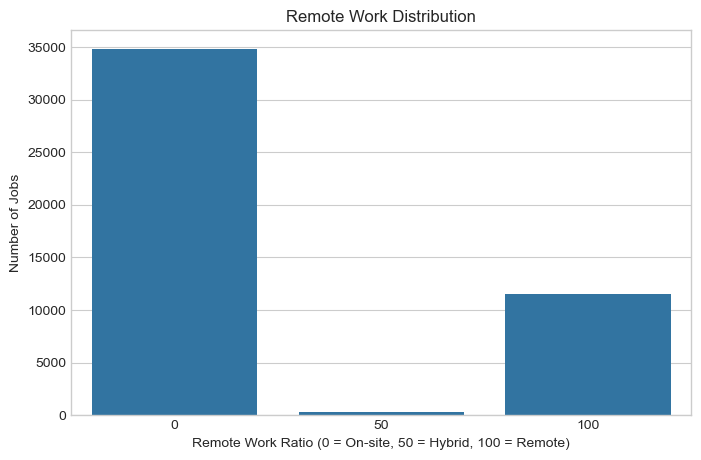

In [32]:
plt.figure(figsize=(8,5))
sns.countplot(x="remote_ratio", data=df_clean)

plt.title("Remote Work Distribution")
plt.xlabel("Remote Work Ratio (0 = On-site, 50 = Hybrid, 100 = Remote)")
plt.ylabel("Number of Jobs")
plt.show()

##### Salary and Remote Work 

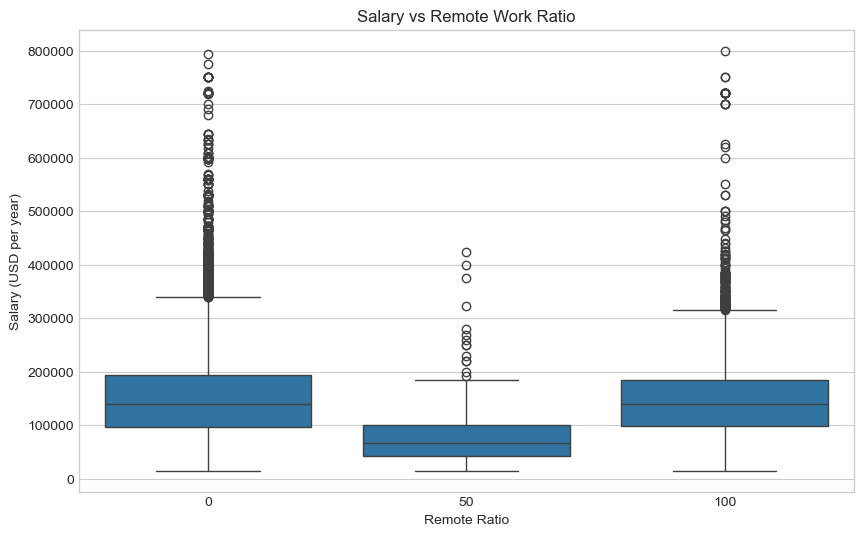

In [33]:
plt.figure(figsize=(10,6))
sns.boxplot(x="remote_ratio", y="salary_in_usd", data=df_clean)

plt.title("Salary vs Remote Work Ratio")
plt.xlabel("Remote Ratio")
plt.ylabel("Salary (USD per year)")
plt.show()

##### Top 10 Most Common Job Titles 

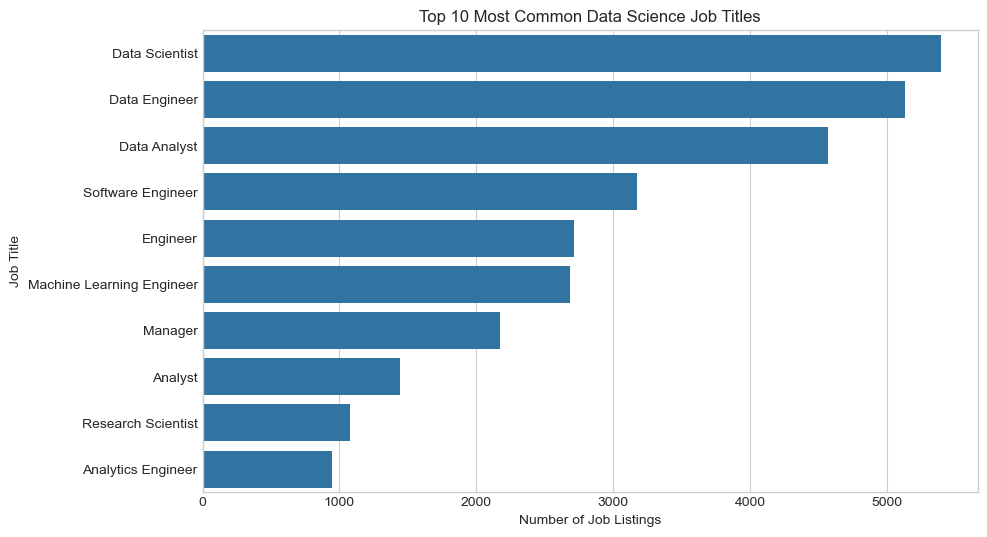

In [34]:
top_jobs = df_clean["job_title"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_jobs.values, y=top_jobs.index)

plt.title("Top 10 Most Common Data Science Job Titles")
plt.xlabel("Number of Job Listings")
plt.ylabel("Job Title")
plt.show()

### Dataset 2 Visualizations & Analysis  

#### Top 30 Skills in Jobs 

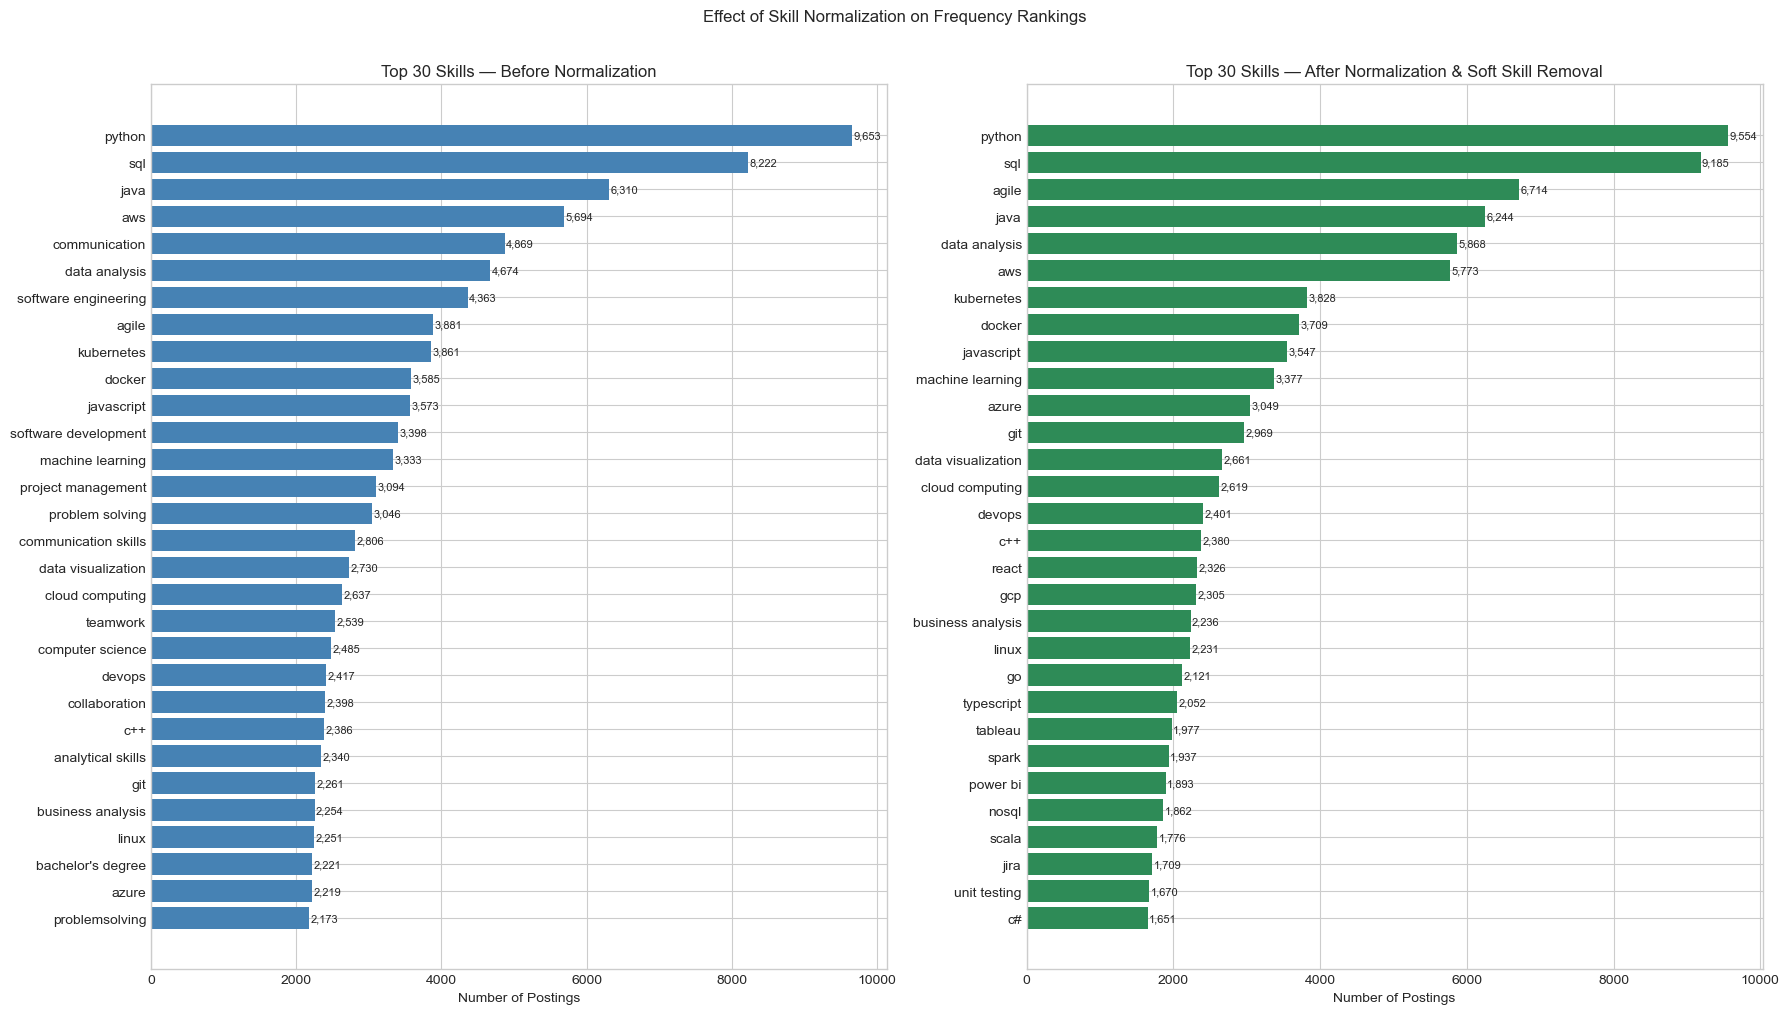

In [35]:
top30_before = pd.DataFrame(all_skills.most_common(30), columns=['skill', 'count'])
top30_after  = pd.DataFrame(all_skills_norm.most_common(30), columns=['skill', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

axes[0].barh(top30_before['skill'][::-1], top30_before['count'][::-1], color='steelblue')
axes[0].set_title('Top 30 Skills — Before Normalization')
axes[0].set_xlabel('Number of Postings')
for i, count in enumerate(top30_before['count'][::-1]):
    axes[0].text(count + 20, i, f'{count:,}', va='center', fontsize=8)

axes[1].barh(top30_after['skill'][::-1], top30_after['count'][::-1], color='seagreen')
axes[1].set_title('Top 30 Skills — After Normalization & Soft Skill Removal')
axes[1].set_xlabel('Number of Postings')
for i, count in enumerate(top30_after['count'][::-1]):
    axes[1].text(count + 20, i, f'{count:,}', va='center', fontsize=8)

plt.suptitle('Effect of Skill Normalization on Frequency Rankings', y=1.01)
plt.tight_layout()
plt.savefig('plots/skills_before_after_normalization.png', dpi=150, bbox_inches='tight')
plt.show()

Cleaning helped! Instead of 95,980 unique skills we now have 95,923. We also found that agile skills are much more in demand, in third place instead of 8th. 

#### Make top 30 skills binary features for ML 

In [36]:
# Build binary feature matrix from top 30 skills
TOP_N = 30
top_skills = [skill for skill, count in all_skills_norm.most_common(TOP_N)]

print(f'Top {TOP_N} skills selected:')
print(top_skills)

#converts skill name into a column. we have 30 new cols and if the job has this skill 
#it'll be marked with a one if it does, 0 if now. this is important for ML
def skill_col(skill):
    return 'has_' + re.sub(r'[^a-z0-9]', '_', skill).strip('_')

for skill in top_skills:
    col = skill_col(skill)
    df[col] = df['skills_normalized'].apply(lambda s: 1 if skill in s else 0)

#print the mean of the binary columns which is the proportion of 1's 
#multiply by 100 to get the percent of job postings that have the skill 
skill_cols = [skill_col(s) for s in top_skills]
print(f'\nSkill prevalence (% of all postings which have this skill):')
print((df[skill_cols].mean() * 100).round(1).sort_values(ascending=False).to_string())

Top 30 skills selected:
['python', 'sql', 'agile', 'java', 'data analysis', 'aws', 'kubernetes', 'docker', 'javascript', 'machine learning', 'azure', 'git', 'data visualization', 'cloud computing', 'devops', 'c++', 'react', 'gcp', 'business analysis', 'linux', 'go', 'typescript', 'tableau', 'spark', 'power bi', 'nosql', 'scala', 'jira', 'unit testing', 'c#']

Skill prevalence (% of all postings which have this skill):
has_python                37.2
has_sql                   35.8
has_agile                 26.1
has_java                  24.3
has_data_analysis         22.9
has_aws                   22.5
has_kubernetes            14.9
has_docker                14.4
has_javascript            13.8
has_machine_learning      13.2
has_azure                 11.9
has_git                   11.6
has_data_visualization    10.4
has_cloud_computing       10.2
has_devops                 9.4
has_react                  9.1
has_gcp                    9.0
has_business_analysis      8.7
has_linux           

In [37]:
# Encode target variables

#create binary column for deciding if job is remote 
df['is_remote'] = (df['job_type'].str.lower() == 'remote').astype(int)

#creates binary column for seniority keywords. if title has any of them, then 1. 
df['is_senior'] = df['job_title'].str.lower().str.contains(
    'senior|sr\\.|lead|staff|principal', na=False
).astype(int)

def categorize_title(title):
    if pd.isna(title):
        return 'other'
    t = title.lower()
    if any(k in t for k in ['machine learning', 'ml engineer', 'ai engineer']):
        return 'ml_engineer'
    if any(k in t for k in ['data scientist', 'research scientist']):
        return 'data_scientist'
    if any(k in t for k in ['data engineer', 'analytics engineer', 'etl', 'database engineer']):
        return 'data_engineer'
    if any(k in t for k in ['data analyst', 'business analyst', 'business intelligence',
                             'bi analyst', 'reporting analyst', 'quantitative analyst']):
        return 'data_analyst'
    if any(k in t for k in ['software engineer', 'software developer', 'backend',
                             'frontend', 'full stack', 'devops', 'cloud engineer',
                             'python developer']):
        return 'software_engineer'
    return 'other'
df['job_category'] = df['job_title'].apply(categorize_title)

print('is_remote rate:', df['is_remote'].mean().round(3))
print('\njob_category distribution:')
print(df['job_category'].value_counts())
print('\nis_senior distribution:')
print(df['is_senior'].value_counts())

is_remote rate: 0.0

job_category distribution:
job_category
software_engineer    13776
data_analyst          7566
data_engineer         2052
ml_engineer            994
data_scientist         840
other                  448
Name: count, dtype: int64

is_senior distribution:
is_senior
1    13445
0    12231
Name: count, dtype: int64


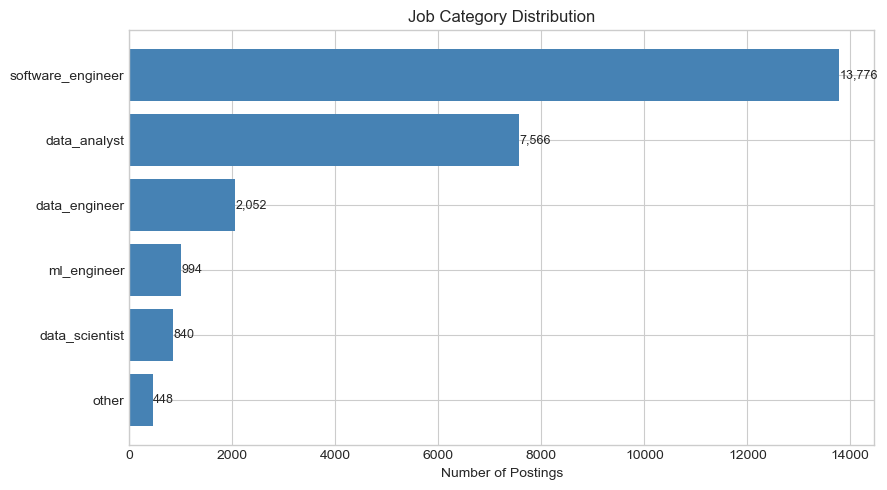

In [38]:
category_counts = df['job_category'].value_counts()

plt.figure(figsize=(9, 5))
plt.barh(category_counts.index[::-1], category_counts.values[::-1], color='steelblue')
plt.title('Job Category Distribution')
plt.xlabel('Number of Postings')
for i, count in enumerate(category_counts.values[::-1]):
    plt.text(count + 10, i, f'{count:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plots/job_category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
print('job_location — top 20 values:')
print(df['job_location'].value_counts().head(20).to_string())

job_location — top 20 values:
job_location
New York, NY                          563
San Francisco, CA                     458
Chicago, IL                           422
London, England, United Kingdom       368
Atlanta, GA                           350
Boston, MA                            334
Austin, TX                            324
Seattle, WA                           298
Dallas, TX                            284
Toronto, Ontario, Canada              267
Washington, DC                        247
Charlotte, NC                         228
Los Angeles, CA                       203
Houston, TX                           198
Annapolis Junction, MD                198
Philadelphia, PA                      197
San Diego, CA                         196
Sydney, New South Wales, Australia    188
Richmond, VA                          181
McLean, VA                            163


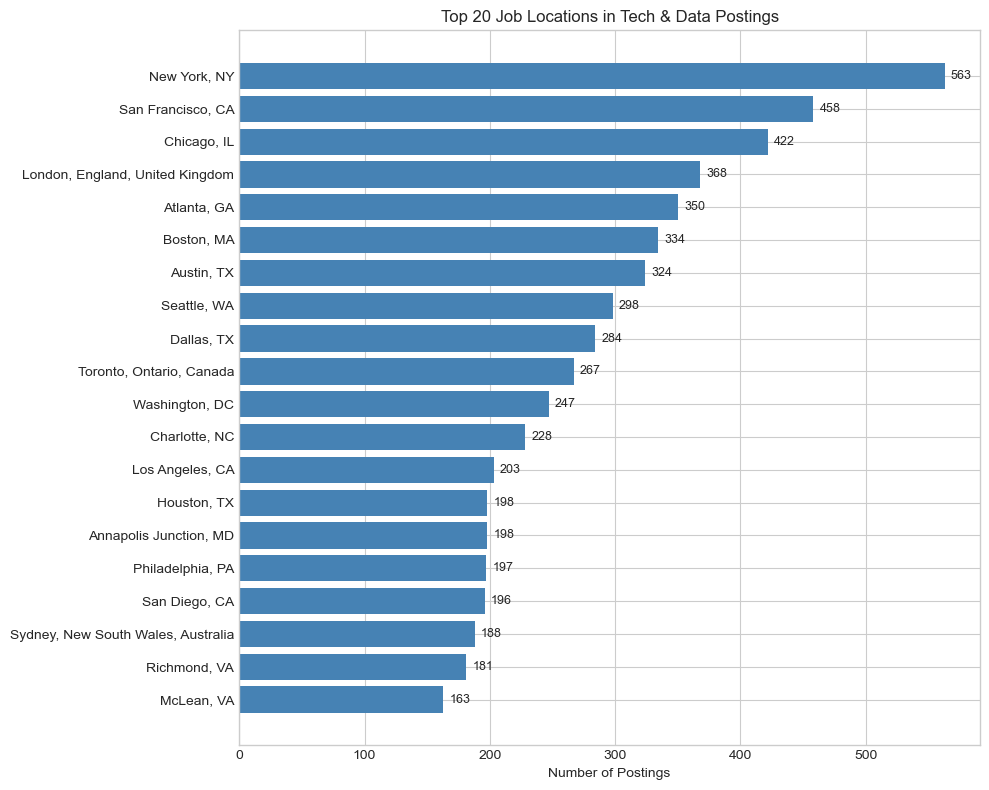

In [40]:
location_counts = df['job_location'].value_counts().head(20)

plt.figure(figsize=(10, 8))
plt.barh(location_counts.index[::-1], location_counts.values[::-1], color='steelblue')
plt.title('Top 20 Job Locations in Tech & Data Postings')
plt.xlabel('Number of Postings')
for i, count in enumerate(location_counts.values[::-1]):
    plt.text(count + 5, i, f'{count:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plots/top20_locations.png', dpi=150, bbox_inches='tight')
plt.show()

#### Complex EDA
#### Skill demand by job category: heatmap of top skills per role

In [41]:
# For each job category, get the top 10 skills and their prevalence
categories = ['data_analyst', 'data_scientist', 'data_engineer', 
               'software_engineer', 'ml_engineer']

category_skill_pct = {}

for cat in categories:
    cat_df = df[df['job_category'] == cat]
    total = len(cat_df)
    skill_pct = {}
    for skill in top_skills:
        col = skill_col(skill)
        pct = cat_df[col].mean() * 100
        skill_pct[skill] = round(pct, 1)
    category_skill_pct[cat] = skill_pct

# Build a dataframe — rows are skills, columns are job categories
heatmap_df = pd.DataFrame(category_skill_pct)

print(heatmap_df.round(1).to_string())

                    data_analyst  data_scientist  data_engineer  software_engineer  ml_engineer
python                      17.0            78.6           67.7               39.2         71.5
sql                         36.5            56.2           69.3               30.5         16.2
agile                       18.1             8.8           27.3               31.9         25.8
java                         2.6            12.4           33.6               36.1         24.2
data analysis               49.7            43.7           26.6                6.6         15.2
aws                          2.7            16.7           34.6               31.7         26.3
kubernetes                   0.2             3.7            8.8               24.9         16.4
docker                       0.3             5.4            8.8               23.8         17.2
javascript                   1.3             2.1            2.1               24.5          1.4
machine learning             5.8        

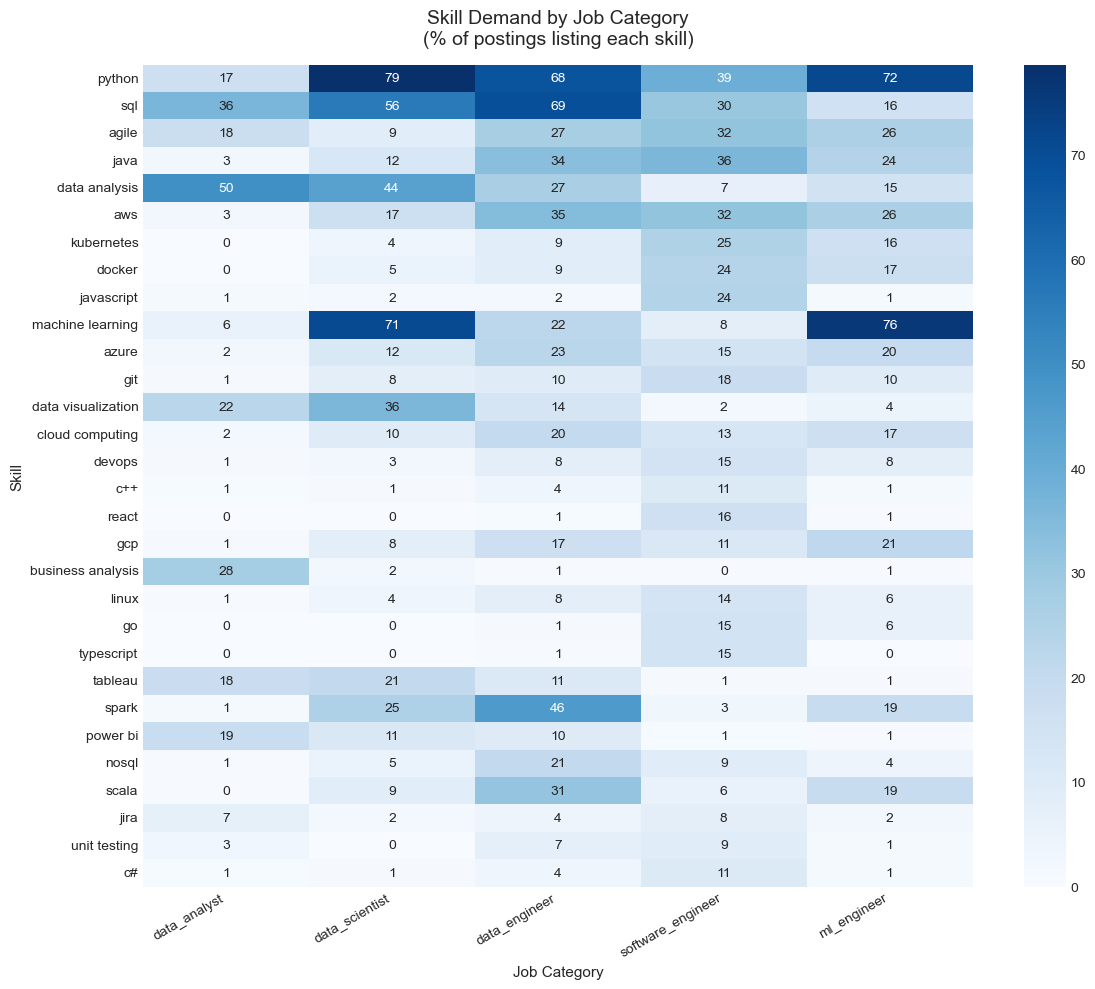

In [42]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.0f',
    cmap = "Blues"
)

plt.title('Skill Demand by Job Category\n(% of postings listing each skill)', fontsize=14, pad=15)
plt.xlabel('Job Category', fontsize=11)
plt.ylabel('Skill', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('plots/skill_demand_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

#### Skill demand by seniority

In [43]:
senior_skill_pct = {}

for level, label in [(1, 'senior'), (0, 'non_senior')]:
    level_df = df[df['is_senior'] == level]
    skill_pct = {}
    for skill in top_skills:
        col = skill_col(skill)
        skill_pct[skill] = round(level_df[col].mean() * 100, 1)
    senior_skill_pct[label] = skill_pct

seniority_df = pd.DataFrame(senior_skill_pct)
seniority_df['difference'] = seniority_df['senior'] - seniority_df['non_senior']
seniority_df = seniority_df.sort_values('difference', ascending=False)

print(seniority_df.to_string())

                    senior  non_senior  difference
aws                   32.2        11.8        20.4
java                  33.6        14.1        19.5
python                44.9        28.8        16.1
kubernetes            22.1         7.0        15.1
docker                21.6         6.6        15.0
go                    13.7         2.3        11.4
azure                 16.7         6.6        10.1
javascript            18.5         8.7         9.8
agile                 30.7        21.2         9.5
typescript            12.4         3.1         9.3
gcp                   13.3         4.2         9.1
cloud computing       14.1         6.0         8.1
react                 12.5         5.2         7.3
scala                 10.3         3.2         7.1
nosql                 10.2         4.0         6.2
linux                 10.8         6.4         4.4
machine learning      15.2        10.9         4.3
sql                   37.8        33.6         4.2
devops                11.3     

How to read: 32.2% of senior job postings list AWS as a required skill, but only 11.8% of non-senior postings do. So AWS shows up in senior roles about 20 percentage points more often than in non-senior roles.
Flip it to data analysis which has -15.7. That means 31.1% of non-senior postings list data analysis, but only 15.4% of senior postings do. So data analysis is much more common in junior/associate roles.

Senior roles demand more: cloud and infrastructure skills dominate — AWS (+20.4), Java (+19.5), Python (+16.1), Kubernetes (+15.1), Docker (+15.0). Senior roles are heavily engineering-oriented.
Non-senior roles demand more: data analysis (-15.7), business analysis (-9.9), power bi (-5.6), data visualization (-5.6), tableau (-4.2). Junior/associate roles skew toward analyst tools and business-facing skills. Conventionally, you enter tech doing analysis and reporting, you advance by building systems and infrastructure. The numbers corroborate this pattern. 

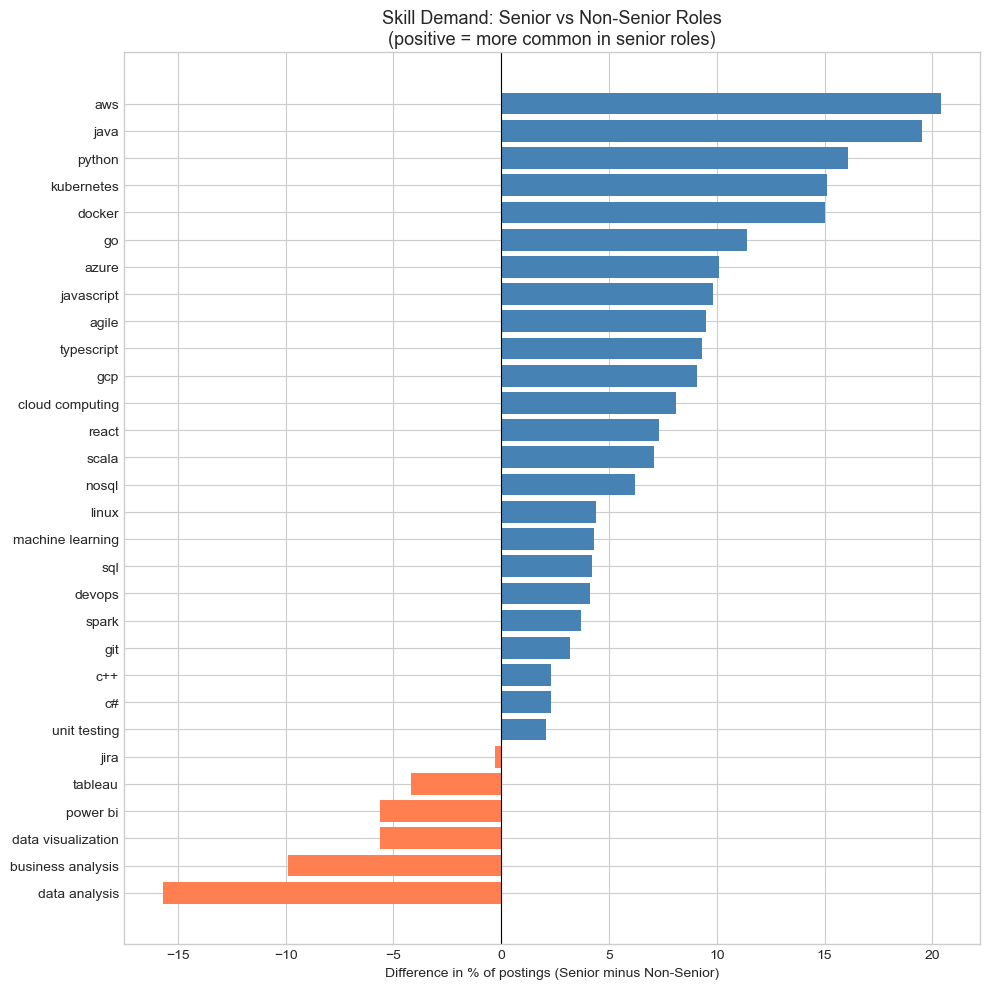

In [44]:
seniority_df_sorted = seniority_df.sort_values('difference')

colors = ['coral' if x < 0 else 'steelblue' for x in seniority_df_sorted['difference']]

plt.figure(figsize=(10, 10))
plt.barh(seniority_df_sorted.index, seniority_df_sorted['difference'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Skill Demand: Senior vs Non-Senior Roles\n(positive = more common in senior roles)', fontsize=13)
plt.xlabel('Difference in % of postings (Senior minus Non-Senior)')

plt.tight_layout()
plt.savefig('plots/skill_seniority_difference.png', dpi=150, bbox_inches='tight')
plt.show()

#### Skills Co-Occurence: which skills appear together in the same job posting

In [45]:
# Build co-occurrence matrix
co_matrix = pd.DataFrame(0, index=top_skills, columns=top_skills)

for skills in df['skills_normalized']:
    skills_in_top = [s for s in skills if s in top_skills]
    for s1 in skills_in_top:
        for s2 in skills_in_top:
            if s1 != s2:
                co_matrix.loc[s1, s2] += 1

# Convert to percentage — out of all postings that have skill A, what % also have skill B
co_pct = co_matrix.copy()
for skill in top_skills:
    col_name = skill_col(skill)
    total = df[col_name].sum()
    if total > 0:
        co_pct.loc[skill] = (co_matrix.loc[skill] / total * 100).round(1)

print('Co-occurrence matrix (% of row skill postings that also list column skill):')
print(co_pct.round(1).to_string())

Co-occurrence matrix (% of row skill postings that also list column skill):
                    python   sql  agile  java  data analysis   aws  kubernetes  docker  javascript  machine learning  azure   git  data visualization  cloud computing  devops   c++  react   gcp  business analysis  linux    go  typescript  tableau  spark  power bi  nosql  scala  jira  unit testing    c#
python                 0.0  57.2   32.3  43.0           24.5  39.2        26.2    25.7        18.4              26.2   20.9  15.9                15.3             18.1    12.8  14.5    9.3  18.1                2.4   13.0  18.3        10.4     12.6   17.5       9.0   14.9   17.0   6.8           5.6   6.4
sql                   59.5   0.0   33.7  37.8           33.8  34.2        22.8    23.3        21.1              17.5   18.2  13.5                19.6             17.0     9.4   5.8   10.4  14.7                6.8    8.5  15.7        11.2     17.4   15.3      13.6   17.9   14.2   7.4           7.7   7.5
agile       

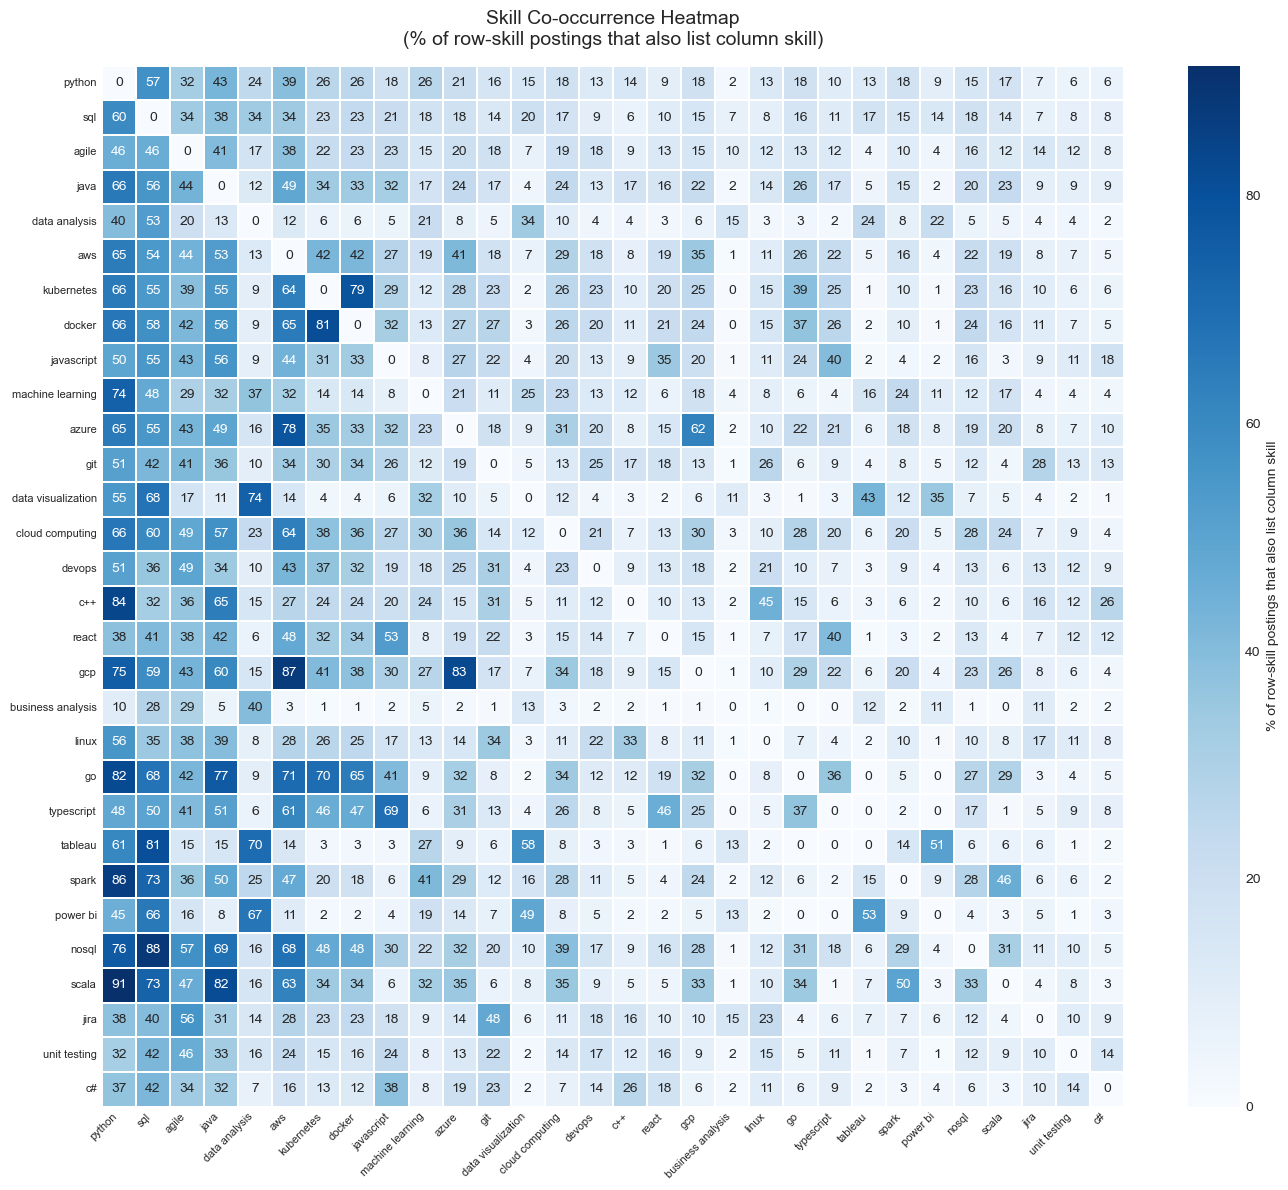

In [46]:
plt.figure(figsize=(14, 12))

sns.heatmap(
    co_pct,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    linewidths=0.3,
    cbar_kws={'label': '% of row-skill postings that also list column skill'}
)

plt.title('Skill Co-occurrence Heatmap\n(% of row-skill postings that also list column skill)', 
          fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig('plots/skill_cooccurrence.png', dpi=150, bbox_inches='tight')
plt.show()

Kubernetes and Docker co-occur at 81%. If a job lists one, it almost always lists the other
GCP and Azure both appear with AWS at 87% and 78%, cloud skills are bundled together.
Tableau and Power BI co-occur at 51-53%, visualization tools travel together.
Scala and Spark co-occur at 46-50%, classic big data pairing.
Business analysis is very isolated, it haslow co-occurrence with almost everything except data analysis!

#### Skills by Location

In [47]:
# Get top 10 cities by posting count
top_cities = df['job_location'].value_counts().head(10).index.tolist()

# For each city, get skill prevalence
city_skill_pct = {}

for city in top_cities:
    city_df = df[df['job_location'] == city]
    skill_pct = {}
    for skill in top_skills:
        col = skill_col(skill)
        skill_pct[skill] = round(city_df[col].mean() * 100, 1)
    city_skill_pct[city] = skill_pct

city_df_heatmap = pd.DataFrame(city_skill_pct)

print(f'Cities included: {top_cities}')
print(f'\nShape: {city_df_heatmap.shape}')
print(city_df_heatmap.to_string())

Cities included: ['New York, NY', 'San Francisco, CA', 'Chicago, IL', 'London, England, United Kingdom', 'Atlanta, GA', 'Boston, MA', 'Austin, TX', 'Seattle, WA', 'Dallas, TX', 'Toronto, Ontario, Canada']

Shape: (30, 10)
                    New York, NY  San Francisco, CA  Chicago, IL  London, England, United Kingdom  Atlanta, GA  Boston, MA  Austin, TX  Seattle, WA  Dallas, TX  Toronto, Ontario, Canada
python                      42.8               42.1         42.4                             42.4         30.0        35.3        37.7         47.3        39.1                      41.9
sql                         34.1               31.9         39.6                             31.5         32.6        38.9        34.6         33.6        41.5                      34.1
agile                       17.1               17.0         29.1                             19.3         24.0        25.1        17.0         13.8        20.8                      30.0
java                        19.0  

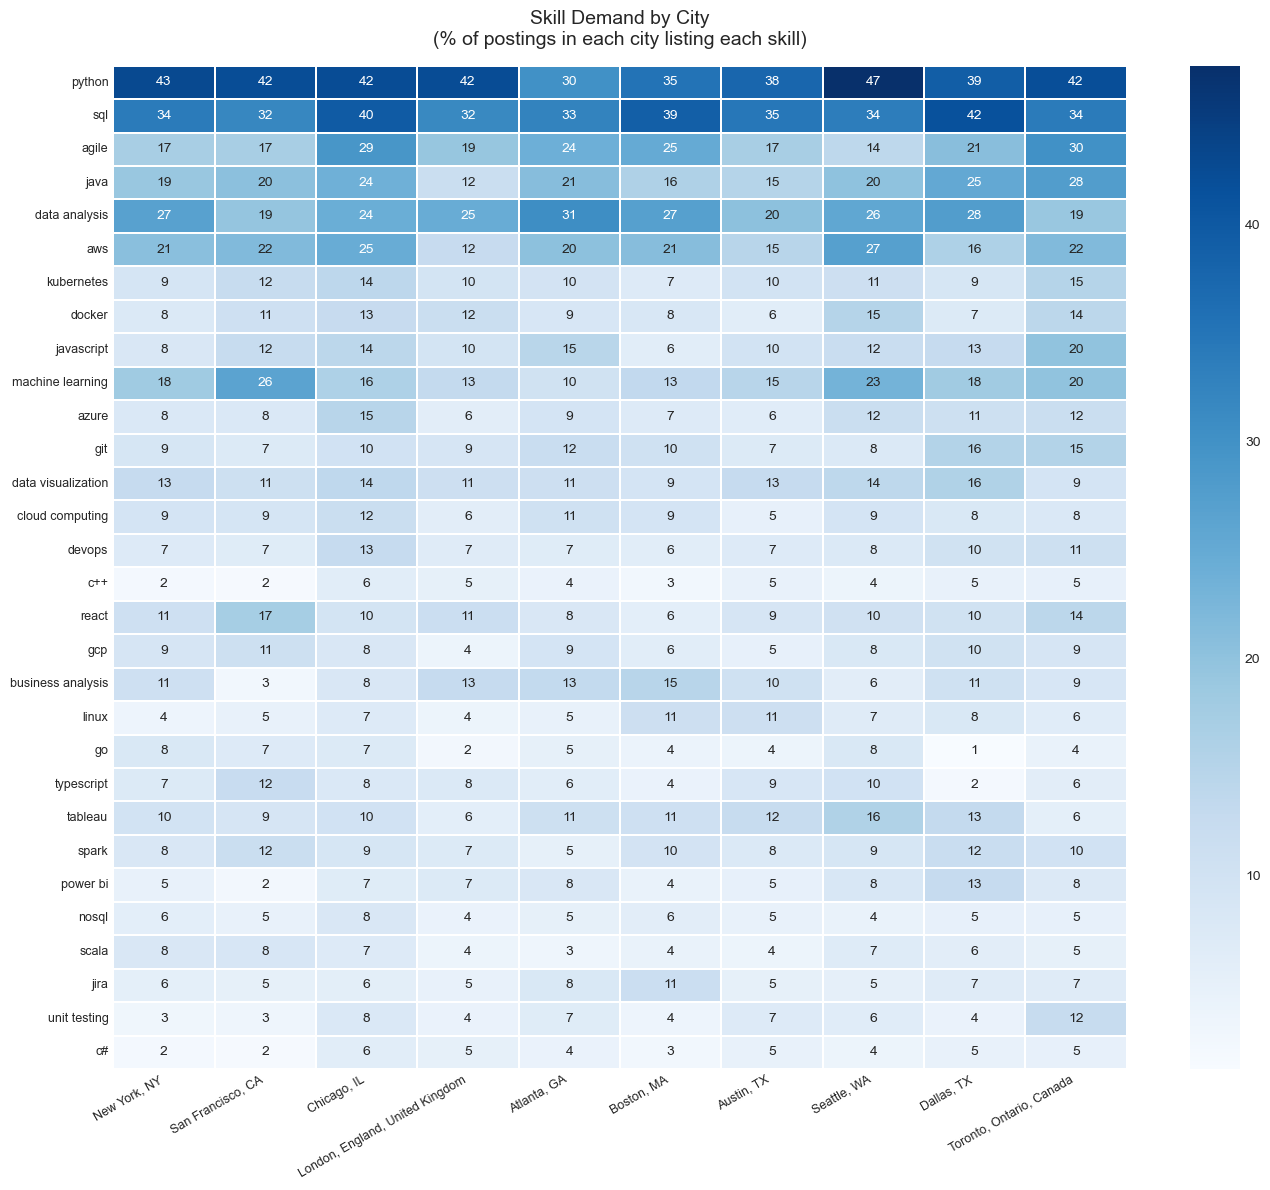

In [48]:
plt.figure(figsize=(14, 12))

sns.heatmap(
    city_df_heatmap,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    linewidths=0.3,
)

plt.title('Skill Demand by City\n(% of postings in each city listing each skill)',
          fontsize=14, pad=15)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('plots/skill_demand_by_city.png', dpi=150, bbox_inches='tight')
plt.show()

San Francisco leads in machine learning (26.4%), which makes sense for the Bay Area which is the leading tech hub of innovation. Seattle is highest for Python (47.3%) and Docker (15.1%) which demonstrates Amazon/Microsoft influence. Toronto stands out for unit testing (12.4%) and agile (30%) showing strong engineering culture. London skews toward business analysis (12.8%) and is lowest for AWS (12.5%) meaning it has more finance/consulting tech roles. Dallas leads in SQL (41.5%) and Power BI (12.7%) shedding light on how it is enterprise/data warehouse heavy.

### Machine Learning

#### Random Forest to Predict Role Type Based on Skills 

In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Features: 30 binary skill columns
# Target: job category
X = df[skill_cols].values
y = df['job_category']

# Remove 'other' category — too mixed to be meaningful
mask = y != 'other'
X = X[mask]
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(f'Training size: {len(X_train):,}')
print(f'Test size:     {len(X_test):,}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred))

Training size: 20,182
Test size:     5,046

Classification Report:
                   precision    recall  f1-score   support

     data_analyst       0.87      0.76      0.81      1513
    data_engineer       0.65      0.48      0.56       411
   data_scientist       0.46      0.33      0.38       168
      ml_engineer       0.60      0.55      0.57       199
software_engineer       0.83      0.95      0.89      2755

         accuracy                           0.82      5046
        macro avg       0.68      0.61      0.64      5046
     weighted avg       0.81      0.82      0.81      5046



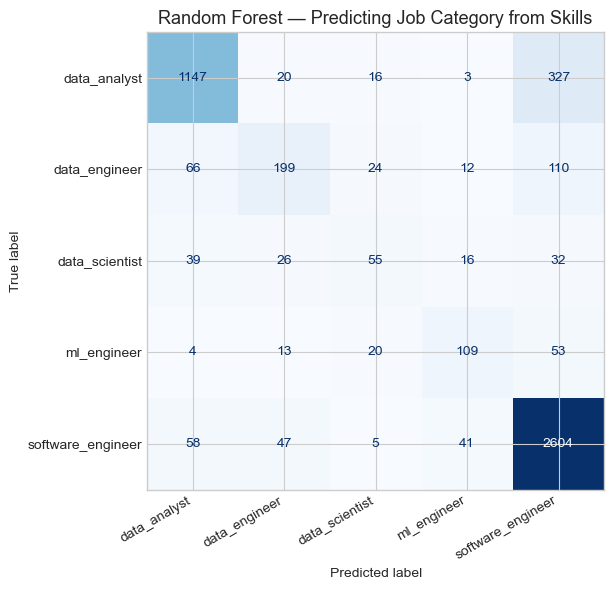

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay

labels = ['data_analyst', 'data_engineer', 'data_scientist', 'ml_engineer', 'software_engineer']

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=plt.gca(), colorbar=False)
plt.title('Random Forest — Predicting Job Category from Skills', fontsize=13)
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig('plots/job_category_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Precision — 87% of the time, the model predicted the role to be data analyst when it actually was that!
Recall — Of all the actual data analyst postings, the model correctly found 76%. 
F1 - overall performance. 

Software engineer at 0.89 F1 score was the easiest to predict. JavaScript, React, TypeScript, Docker, Kubernetes are very distinctive signals. Data analyst (0.81 F1) was also strong. SQL, Tableau, Power BI, business analysis are clear markers. Data engineer at 0.56 F1 was harder to predict as there was likely skill overlap with both data analysts and software engineers. ML engineer (0.57 F1) has a similar issue as it overlaps heavily with data scientists. And data scientist at 0.38 F1 was the worst performer as these roles borrow from analyst, ML, and engineering skill sets simultaneously

#### Random Forest to Predict Seniority based on Skills 

In [51]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

X = df[skill_cols].values
y = df['is_senior']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_senior = RandomForestClassifier(n_estimators=100, random_state=42)
rf_senior.fit(X_train, y_train)
y_pred = rf_senior.predict(X_test)

print(f'Training size: {len(X_train):,}')
print(f'Test size:     {len(X_test):,}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred))

Training size: 20,540
Test size:     5,136

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.72      0.68      2447
           1       0.71      0.63      0.67      2689

    accuracy                           0.67      5136
   macro avg       0.67      0.67      0.67      5136
weighted avg       0.68      0.67      0.67      5136



Given the 67% f1-score, we can determine that the model is right about seniority 2 out of 3 times just from looking at skills. That's decent but it means 1 in 3 jobs is misclassified. Skills alone aren't enough to reliably separate senior from non-senior.

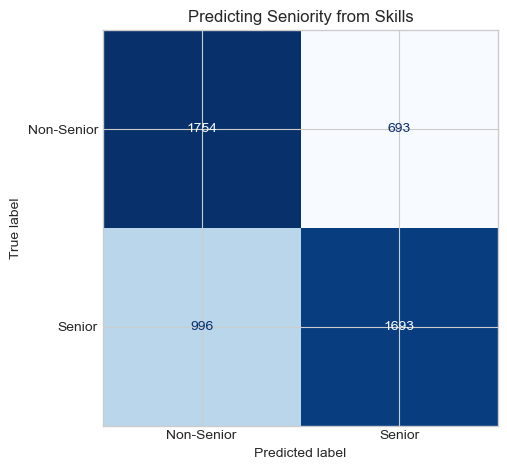

In [52]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Senior', 'Senior'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Predicting Seniority from Skills')
plt.tight_layout()
plt.savefig('plots/seniority_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Ethics

Instructions: Keep the contents of this cell. For each item on the checklist
-  put an X there if you've considered the item
-  IF THE ITEM IS RELEVANT place a short paragraph after the checklist item discussing the issue.
  
Items on this checklist are meant to provoke discussion among good-faith actors who take their ethical responsibilities seriously. Your teams will document these discussions and decisions for posterity using this section.  You don't have to solve these problems, you just have to acknowledge any potential harm no matter how unlikely.

Here is a [list of real world examples](https://deon.drivendata.org/examples/) for each item in the checklist that can refer to.

[![Deon badge](https://img.shields.io/badge/ethics%20checklist-deon-brightgreen.svg?style=popout-square)](http://deon.drivendata.org/)

### A. Data Collection
 - [] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?
 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?
> We are concerned that the data itself may be biased or incomplete. Not all entry-level software engineering jobs are posted online, since some people get jobs through referrals, internal hiring, or campus recruiting that does not appear on job boards. Because of this, it is difficult to collect data that fully represents the true number of available jobs, which may affect the accuracy of the comparison.

 - [ ] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?
 - [ ] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?
> The data used in this project is publicly available and does not include any private information. It is stored locally during the analysis, and basic care is taken to avoid accidentally changing or sharing the files. Because the data is low risk, no special security measures are needed.

 - [ ] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?
 - [ ] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?
> This project looks at overall numbers and trends, so it does not include personal experiences from recent graduates or employers. Because of this, the results may not fully explain why certain trends happen, and they should be understood as showing general patterns rather than individual experiences.

 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?
> The LinkedIn dataset skews toward mid-sized and large companies, which means smaller startups and non-traditional tech employers are underrepresented. Skill labels in job postings are also employer-determined and may not accurately reflect what a role actually requires day to day.

 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?
> The results are presented in a way that avoids oversimplifying or exaggerating the data. Instead of focusing on single-year changes, the analysis looks at overall trends across multiple years to reduce the impact of short-term fluctuations. All figures and summaries are explained in context so readers understand what the data shows and what it does not show.

 - [ ] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?
 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?
> The steps of the analysis, including data sources and processing methods, are documented so that the work can be checked or repeated by others if needed, which also helps maintain transparency and accountability.


### D. Modeling
 - [ ] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?
> Our model predicts job category and seniority based on which skills appear in a job posting. But not everyone has had the same opportunity to learn these skills. Someone from a non-traditional background or without access to formal training may list fewer skills, not because they are less qualified, but because they had fewer resources. This means the model could unintentionally disadvantage candidates who took a different path into tech.
 - [ ] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?
 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?
> The main metrics we used were skill frequency, classification accuracy, and salary distribution. These do a good job capturing broad hiring patterns, but they don't tell the whole story,  things like job quality, company culture, or whether a listed skill is truly required versus just nice to have are harder to measure and weren't captured here.

 - [ ] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
> Random Forest models are not fully transparent, but feature importance scores that can show which skills most influenced a prediction. This makes the model's decisions partially explainable, though not in a way that would satisfy a high-stakes hiring decision.
 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?
> The final results clearly explain the limitations of the analysis, including data gaps and simplifying assumptions, so readers understand what the results do and do not show.

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
> This analysis is based on data from a specific time period. If it were updated in the future, the data and methods would need to be checked again to make sure they still reflect current job market conditions.

 - [ ] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
 - [ ] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?
> There is a possibility that the results could be misunderstood or used to discourage students from majoring in Computer Science. To reduce this risk, the analysis emphasizes that it describes overall trends in the job market and does not predict individual outcomes or career success.


## Discusison and Conclusion

In this project, we set out to answer a question that felt personal to all of us as students preparing to enter the tech job market: what technical skills are actually demanded in tech and data roles, and how do these skill demands, salary expectations, and remote work availability differ across the modern job market? To investigate this, we analyzed over 25,000 tech-relevant LinkedIn job postings alongside a supplementary dataset of 93,000 data science salary records from 2024. Our original hypothesis posited that Python, SQL, and cloud platforms would be the most universally demanded skills, with Python dominating Data Science roles and SQL characterizing Analyst roles. We further predicted that roles requiring machine learning and cloud skills would command statistically higher median salaries, controlling for experience and company size, and show strong positive associations with remote work.

Our analysis largely confirmed the foundational dominance of core data tools, with Python and SQL emerging as the top two most frequently requested technical skills across the job market. The expected skill divergence by role was heavily supported: Python appeared in 79% of Data Scientist postings, while SQL was a defining requirement for Data Engineers and Analysts. However, other parts of our analysis gave us some unexpected results. For instance, while we found that advanced cloud skills like AWS are heavily concentrated in upper-level roles (appearing in 32.2% of senior postings versus 11.8% of non-senior ones), our Random Forest model revealed that technical skills alone are a relatively poor predictor of seniority, achieving only 67% accuracy. With a near 50/50 split between senior and non-senior roles in our dataset, chance performance would sit around 50%, meaning our model's 67% accuracy is only modestly better than chance, showing that skills alone aren't enough to consistently predict seniority. This suggests that seniority in tech is defined more by experience, leadership, and judgment that can't be measured by a skills list than by simply building up a larger stack of technical skills. Regarding compensation, the data cleanly demonstrated that salaries scale fundamentally with experience, moving from roughly 90,000 dollars at the entry level to a heavily right skewed distribution exceeding $200,000 for executives. However, because we did not run direct statistical tests linking specific niche skills to higher median salaries or track how skill demand changed from 2020 to 2024, those specific parts of our hypothesis remain inconclusive.

These findings directly build upon and extend the prior research outlined in our background investigation. While broader reports from McKinsey (2023) and the World Economic Forum (2023) highlighted rapid growth in the demand for data, cloud computing, and machine learning skills, they didn't examine how these skills translate to specific outcomes in the job market. Our project filled this gap by connecting these broader trends to concrete salary distributions and seniority levels. Furthermore, we expanded on earlier observational studies, such as Sadafian's (2026) analysis of LinkedIn postings, which identified baseline SQL and Python frequencies of 55% and 41%, respectively. Rather than just describing skill frequencies, our Random Forest models tested the predictive power of these skills on job category and seniority, successfully moving the analysis from descriptive statistics to predictive insights.

Although this analysis gives a broad overview of the tech job market, there are several significant limitations that need to be noted. First, LinkedIn represents only approximately a quarter of the online job board market and skews toward mid-sized and large enterprises, meaning startup hiring is largely absent from our data. Additionally, our reliance on public postings means the dataset underrepresents roles filled through alternative pathways, such as internal promotions, university campus recruiting, and professional referrals. The seniority and job level labels attached to these postings are also employer-determined proxy measurements; they signal seniority without directly measuring the experience, leadership, or judgment that actually defines it. Furthermore, our compensation insights, drawn from self-reported Kaggle records, are self-reported and may not be reliable enough to use as a precise benchmark. Finally, this analysis relies entirely on quantitative data, lacking the qualitative context from actual workers or hiring managers that could explain the why behind these hiring trends.

The real-world impact of this work is its ability to cut through the noise in a confusing and competitive hiring market. For early-career professionals, university students, and those transitioning into the tech industry, navigating the sheer volume of potential tools to learn can be overwhelming. By grounding these requirements in real data,  showing, for instance, that mastering Python and SQL is a much better use of your time than chasing niche tools, this analysis offers actionable, data-driven guidance for educational and career development. By showing the heavy right-skew of tech salaries and demonstrating why the median is a much safer benchmark than the mean, this work empowers job seekers to enter compensation negotiations with realistic, evidence-based expectations, helping build a more transparent and equitable tech job market.

If this investigation were to continue beyond the scope of this class, the logical next step would be to transition from a cross-sectional analysis to a longitudinal one. Tracking skill demand, remote work availability, and salary fluctuations over multiple years would reveal how quickly new technologies replace older ones, rather than just looking at one point in time like 2024. Additionally, applying NLP techniques like TF-IDF to the full text of job descriptions, rather than just relying on keyword tags, could uncover deeper details about soft skills, educational requirements, and the specific ways in which tools like Python or AWS are actually being applied in day-to-day operations, while sentiment analysis could reveal how differently employers frame those same expectations across industries and company sizes.
